# Running Footwear & Apparel Case Study - Clustering

-----------------------------------------
## Objective
-----------------------------------------

To implements unsupervised learning techniques to consult a running footwear & apparel company on strategic decisions regarding their running product & marketing.

-----------------------------------------
## Author
-----------------------------------------
Balbina Salas

------------------------
## Data Dictionary
-------------------------

The data contains participants that answered a survey related to questions relevant to the running footwear and apparel company.
- record: Dataset record number.	
- id: Unique identifier for survey participant.	
- The following are applicable for remaining attributes:
    - 0	Unchecked
    - 1	Checked
- country:	Country represented by participant (A1r1-A1r3).	
    - S1r1:	United States
    -	S1r2:	United Kingdom
    - S1r3:	Japan
- verification:	Indication whether participant is valid or not for survey participation.	 
    - S2r1:	Valid
    - S2r2:	Invalid
-gender:	Participant gender.	
    - S3r1:	Male
    - S3r2:	Female
-age:	Participant age.	
    - S4r1:	Under 18
    - S4r2:	18-24
    - S4r3:	25-34
    - S4r4:	35-44
    - S4r5:	45-54
    - S4r6:	Above 55
-Q1:	How regularly do you go for a run?	
    - Q1r1:	Occasionally when the weather is nice.
    - Q1r2:	Fairly regularly around 3-4 times a week.
    - Q1r3:	Generally 5+ times a week.
-Q2	How many pairs of running shoes do you own at a time when you train?	
    - Q2r1:	A single pair that I use to go running in and also use for other activities.
    - Q2r2:	1 pair of running shoes that I only use to run in.
    - Q2r3:	3+ pairs of running shoes, some that I use for training and others that I use to race.
    - Q2r4:	5+ pairs of running shoes depending on the type of training and racing that I'm doing.
-Q3	What type of cushioning do the shoes that you train in most regularly use?	
    - Q3r1:	I'm not sure
    - Q3r2:	Foam
    - Q3r3:	Rubber
    - Q3r4:	Blend of foam & rubber
-Q4	What type of plating do the shoes that you race in use?	
    - Q4r1:	I don't run races
    - Q4r2:	I use the same shoes I train in to run races
    - Q4r3:	Rubber
    - Q4r4:	Foam
    - Q4r5:	Carbon Plate
-Q5	What physical activities do you do outside of running?	
    - Q5r1:	Activities like yoga and pilates
    - Q5r2:	Nothing outside of running
    - Q5r3:	Spinning
    - Q5r4:	Strength conditioning like lifting
    - Q5r5:	Swimming
    - Q5r6:	Hiking
-Q6	What is your top complaint about the shoe you use to run in most regularly?	
    - Q6r1:	I have no complaints!
    - Q6r2:	They wear out too fast and I'm always having to buy new ones.
    - Q6r3:	They feel too narrow for my feet.
    - Q6r4:	They are too heavy.
    - Q6r5:	They feel great but don't feel fashionable.
-Q7	What colors do you prefer for the shoes you run in most often?	
    - Q7r1:	Anything bright & bold
    - Q7r2:	Soft pastels - pink, coral, purple
    - Q7r3:	Earth tones - greens, yellows, browns
    - Q7r4:	Neutrals - black & white
    - Q7r5:	Something normal, no strong preference






## Import Libraries & Data Overview :

In [46]:
#Import all the necessary packages

import pandas as pd
import numpy as np

import matplotlib.pylab as plt
import seaborn as sns

#to scale the data using z-score 
from sklearn.preprocessing import StandardScaler

#importing clustering algorithms
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

#Silhouette score
from sklearn.metrics import silhouette_score

import pandas as pd
from sklearn.metrics.pairwise import pairwise_distances

import warnings
warnings.filterwarnings("ignore")




### Loading Data

In [37]:
#Uploding dataset
from google.colab import files
uploaded = files.upload()

Saving survey_data.csv to survey_data (1).csv


In [47]:
#Reading the dataset
df = pd.read_csv('survey_data.csv')

In [48]:
#Printing head of data set
df.head()

,record,id,S1r1,S1r2,S1r3,S2r1,S2r2,S3r1,S3r2,S4r1,...,Q6r1,Q6r2,Q6r3,Q6r4,Q6r5,Q7r1,Q7r2,Q7r3,Q7r4,Q7r5
0,1,9731743,1,0,0,1,0,1,0,0,...,0,1,0,1,0,0,0,1,1,0
1,2,5917428,0,0,1,1,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
2,3,2459391,0,0,1,1,0,0,1,0,...,0,0,0,0,1,0,1,1,0,0
3,4,3277896,0,0,1,1,0,0,1,0,...,0,0,0,0,1,0,1,0,0,0
4,5,4986375,1,0,0,1,0,0,1,1,...,0,0,0,0,1,1,0,0,0,0


### Checking info on the data

In [49]:
#Printing info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   record  175 non-null    int64
 1   id      175 non-null    int64
 2   S1r1    175 non-null    int64
 3   S1r2    175 non-null    int64
 4   S1r3    175 non-null    int64
 5   S2r1    175 non-null    int64
 6   S2r2    175 non-null    int64
 7   S3r1    175 non-null    int64
 8   S3r2    175 non-null    int64
 9   S4r1    175 non-null    int64
 10  S4r2    175 non-null    int64
 11  S4r3    175 non-null    int64
 12  S4r4    175 non-null    int64
 13  S4r5    175 non-null    int64
 14  S4r6    175 non-null    int64
 15  Q1r1    175 non-null    int64
 16  Q1r2    175 non-null    int64
 17  Q1r3    175 non-null    int64
 18  Q2r1    175 non-null    int64
 19  Q2r2    175 non-null    int64
 20  Q2r3    175 non-null    int64
 21  Q2r4    175 non-null    int64
 22  Q3r1    175 non-null    int64
 23  Q3r2    175 non

**Observations:**
- There are 175 observations and 47 columns.
- All the column have 175 non-null values i.e. there are no missing values in the data.
- All columns are numerical

In [50]:
#checking unique values in each column
df.nunique()

record    175
id        175
S1r1        2
S1r2        2
S1r3        2
S2r1        2
S2r2        2
S3r1        2
S3r2        2
S4r1        2
S4r2        2
S4r3        2
S4r4        2
S4r5        2
S4r6        2
Q1r1        2
Q1r2        2
Q1r3        2
Q2r1        2
Q2r2        2
Q2r3        2
Q2r4        2
Q3r1        2
Q3r2        2
Q3r3        2
Q3r4        2
Q4r1        2
Q4r2        2
Q4r3        2
Q4r4        2
Q4r5        2
Q5r1        2
Q5r2        2
Q5r3        2
Q5r4        2
Q5r5        2
Q5r6        2
Q6r1        2
Q6r2        2
Q6r3        2
Q6r4        2
Q6r5        2
Q7r1        2
Q7r2        2
Q7r3        2
Q7r4        2
Q7r5        2
dtype: int64

**Observations:**
- Record and ID have 175 unique values. However, we can determine a binary data set for the other attributes where the inputs are either 0s and 1s.
- We can drop Record and ID as they won't add value to the analysis. 
- We will also only include valid surveys based on S2r2 which indicates if the participant is valid for the survey participation.

In [51]:
# checking for duplicate values in the data
print('Number of duplicated records in raw data: ',df.duplicated().sum())
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print('The shape of data after removing duplicated values: ',df.shape)
print('Number of duplicated records after removing duplicates: ',df.duplicated().sum())

Number of duplicated records in raw data:  0
The shape of data after removing duplicated values:  (175, 47)
Number of duplicated records after removing duplicates:  0


- Since there were no duplicated values, no values were removed. Data contains only unique set of records.

## Exploratory Analysis

### Analysis of data columns

Since we don't need record and id, we can drop these columns. Also, columns S2r1 and S2r2 indicate whether participant is valid or not for survey participation. We will drop entries from S2r2 that contain a 1 since those would be considered as invalid.

In [52]:
#dropping record column
df=df.drop("record", axis=1)
#dropping id column
df=df.drop("id", axis=1)
#keeping records under S2r2 where values are not equal to 1. If values under S2r2 are 1 it means the surveys are invalid.
df_new = df[df['S2r2']!=1]
df_new

,S1r1,S1r2,S1r3,S2r1,S2r2,S3r1,S3r2,S4r1,S4r2,S4r3,...,Q6r1,Q6r2,Q6r3,Q6r4,Q6r5,Q7r1,Q7r2,Q7r3,Q7r4,Q7r5
0,1,0,0,1,0,1,0,0,0,0,...,0,1,0,1,0,0,0,1,1,0
1,0,0,1,1,0,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
2,0,0,1,1,0,0,1,0,1,0,...,0,0,0,0,1,0,1,1,0,0
3,0,0,1,1,0,0,1,0,0,0,...,0,0,0,0,1,0,1,0,0,0
4,1,0,0,1,0,0,1,1,0,0,...,0,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,1,0,0,1,0,0,1,0,0,1,...,0,0,0,0,1,0,0,1,0,0
171,0,1,0,1,0,0,1,0,0,1,...,0,0,0,0,1,0,0,1,0,0
172,1,0,0,1,0,0,1,0,0,1,...,1,0,0,0,0,0,0,0,1,1
173,1,0,0,1,0,0,1,0,1,0,...,0,0,0,0,1,0,0,1,0,0


Observations:
- Important to note that if we had filter out by the valid column (S2r1), we would have ended up with 151 entries. However, a closer look at the data reveals that these two entries are marked as valid for the valid column (S2r1) and invalid for the invalid column (S2r2). Since two surveys can't be marked as valid and invalid at the same time, these two entries were removed. 
- Before we had 175 rows with 47 columns, now we have 149 rows with 45 columns. Therefore, there were 26 participants that were invalid for survey participation.

In [53]:
#Printing the % sub categories of each category
for i in df_new:
    print(df_new[i].value_counts(normalize=True))
    print('*'*40)

1    0.657718
0    0.342282
Name: S1r1, dtype: float64
****************************************
0    0.832215
1    0.167785
Name: S1r2, dtype: float64
****************************************
0    0.825503
1    0.174497
Name: S1r3, dtype: float64
****************************************
1    1.0
Name: S2r1, dtype: float64
****************************************
0    1.0
Name: S2r2, dtype: float64
****************************************
0    0.510067
1    0.489933
Name: S3r1, dtype: float64
****************************************
1    0.510067
0    0.489933
Name: S3r2, dtype: float64
****************************************
0    0.778523
1    0.221477
Name: S4r1, dtype: float64
****************************************
0    0.852349
1    0.147651
Name: S4r2, dtype: float64
****************************************
0    0.751678
1    0.248322
Name: S4r3, dtype: float64
****************************************
0    0.744966
1    0.255034
Name: S4r4, dtype: float64
***********************

**Observations:**

- For S1r1 which is participants from the USA, out of the 149 participants, 65.7% are from the USA. 16.7% are from UK (S1r2) and 17.4% are from Japan (S1r3).
- Similarly, males account for 48.9% (S3r1) whereas females (S3r2) account for 51% of the data.
- Participants under 18 years old account for 22.1%. Participants between 18-24 years account for 14.7%. Participants between 25-34 years account for 24.8%. Participants between 35-44 years account for 25.5%. Participants from 45-54 years account for 10% and above 55 years account for 2%. 
- Similar obervation can be drawn from the other attributes like how regular participants go for a run. 33% say they go occasionally when the weather is nice. 35% say they go fairly regularly around 3-4 times a week and 30% also say they go generally 5+ times a week. It would be interesting to see what % of each group are female or what group age or country they belong to.

### Let's visualize groups more closely

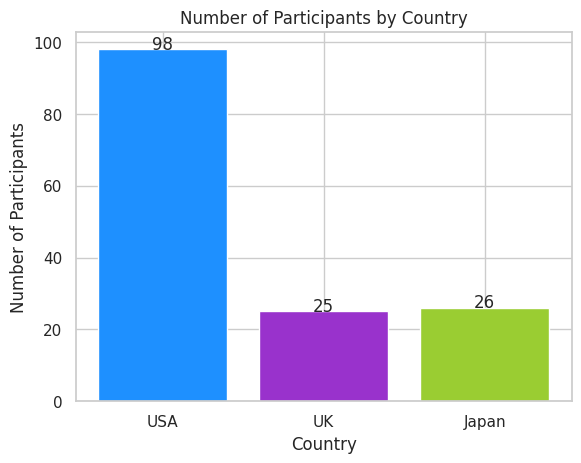

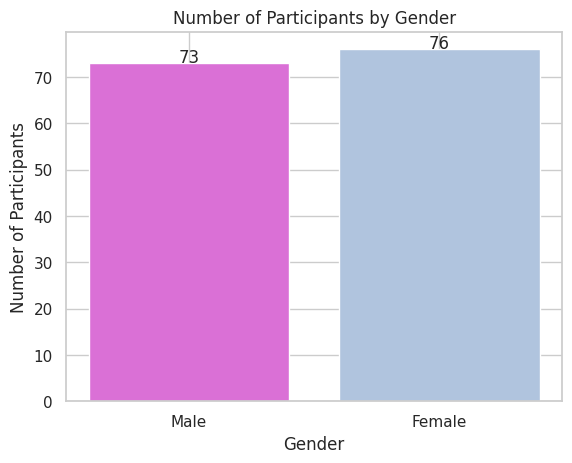

In [54]:
## Visualization by country
counts = df_new[['S1r1', 'S1r2', 'S1r3']].sum()
# creating a bar plot with the counts
colors = ['dodgerblue',  'darkorchid','yellowgreen']
plt.bar(range(len(counts)), counts.values, color=colors)

# Changing axis
plt.xticks(range(len(counts)), ['USA', 'UK', 'Japan'])

# adding labels to the plot
plt.title('Number of Participants by Country')
plt.xlabel('Country')
plt.ylabel('Number of Participants')

# adding total counts for each bar on the plot
for i, v in enumerate(counts.values):
    plt.text(i, v+0.1, str(v), ha='center')

# showing the plot
plt.show()

## Visualization by gender
counts = df_new[['S3r1', 'S3r2']].sum()
# creating a bar plot with the counts
colors = ['orchid',  'lightsteelblue','orange']
plt.bar(range(len(counts)), counts.values, color=colors)

# Changing axis
plt.xticks(range(len(counts)), ['Male', 'Female'])

# adding labels to the plot
plt.title('Number of Participants by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Participants')


# adding total counts for each bar on the plot
for i, v in enumerate(counts.values):
    plt.text(i, v+0.1, str(v), ha='center')

# showing the plot
plt.show()

**Observations:**

- There are more participants from the USA than UK and Japan combined. Therefore, recomnedations to the USA market may have more weight than in UK and Japan.
- There are three more females than males in the entire data set which provides a good point of reference as we have almost equally number of males and females. 

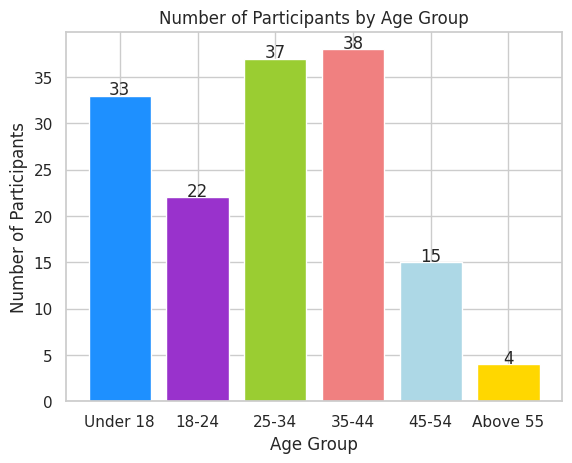

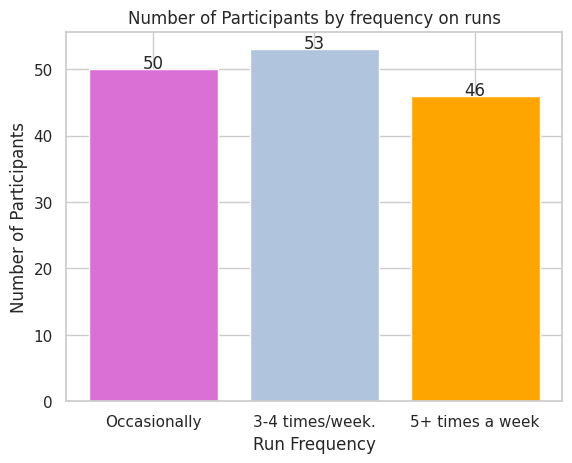

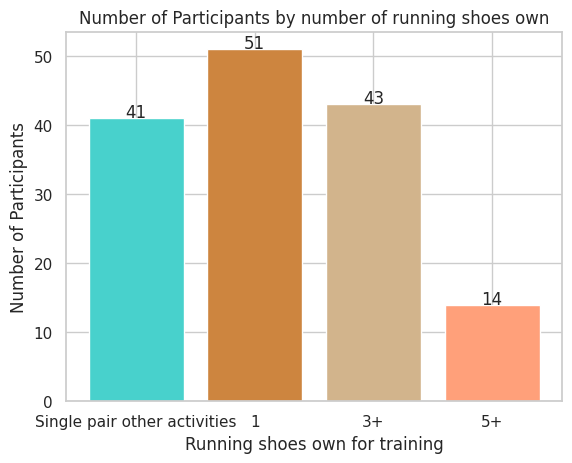

In [55]:
## Visualizing age group
counts = df_new[['S4r1', 'S4r2', 'S4r3','S4r4','S4r5','S4r6']].sum()
# creating a bar plot with the counts
colors = ['dodgerblue',  'darkorchid','yellowgreen', 'lightcoral', 'lightblue', 'gold']
plt.bar(range(len(counts)), counts.values, color=colors)

# Changing axis
plt.xticks(range(len(counts)), ['Under 18',	'18-24',	'25-34',	'35-44',	'45-54',	'Above 55'])

# adding labels to the plot
plt.title('Number of Participants by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Participants')


# adding total counts for each bar on the plot
for i, v in enumerate(counts.values):
    plt.text(i, v+0.1, str(v), ha='center')

# showing the plot
plt.show()

## Visualizing based on how often they go on runs
counts = df_new[['Q1r1',	'Q1r2',	'Q1r3']].sum()
# creating a bar plot with the counts
colors = ['orchid',  'lightsteelblue','orange']
plt.bar(range(len(counts)), counts.values, color=colors)

# Changing axis
plt.xticks(range(len(counts)), ['Occasionally','3-4 times/week.','5+ times a week'])

# adding labels to the plot
plt.title('Number of Participants by frequency on runs')
plt.xlabel('Run Frequency')
plt.ylabel('Number of Participants')


# adding total counts for each bar on the plot
for i, v in enumerate(counts.values):
    plt.text(i, v+0.1, str(v), ha='center')

# showing the plot
plt.show()

## Visualization by how many running shoes they own when they train
counts = df_new[['Q2r1',	'Q2r2',	'Q2r3',	'Q2r4']].sum()
# creating a bar plot with the counts
colors = ['mediumturquoise',  'peru','tan', 'lightsalmon']
plt.bar(range(len(counts)), counts.values, color=colors)

# Changing axis
plt.xticks(range(len(counts)), ['Single pair other activities','1','3+','5+'])

# adding labels to the plot
plt.title('Number of Participants by number of running shoes own')
plt.xlabel('Running shoes own for training')
plt.ylabel('Number of Participants')


# adding total counts for each bar on the plot
for i, v in enumerate(counts.values):
    plt.text(i, v+0.1, str(v), ha='center')

# showing the plot
plt.show()

**Observations:**

- The data shows a skewness towards people under the age of 44 as most of the data includes participants from this age group. Out of the 149 participants, only 19 participants are 45 years or older which makes sense since as we age, we tend to decrease our physical activity.
- In contraste, data has a good distribution between people who run ocassinally vs 3 or 4 times a week vs more than 5 times a week. 
- Most of the participants have either 1 to 3+ (but less than 5) running shoes. A significant number only owns a single pair that they use for running and also for other activities. Only 14 participants have more than 5 running shoes.

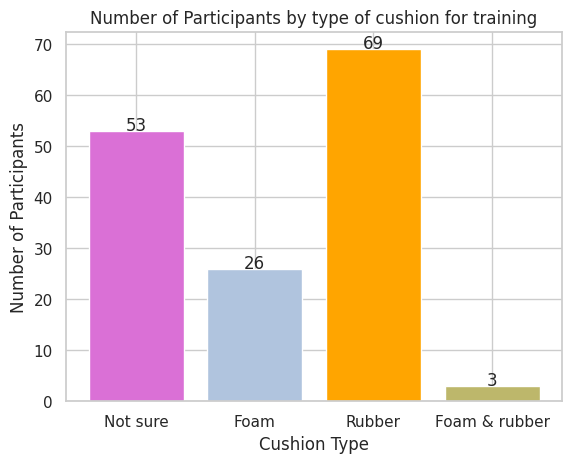

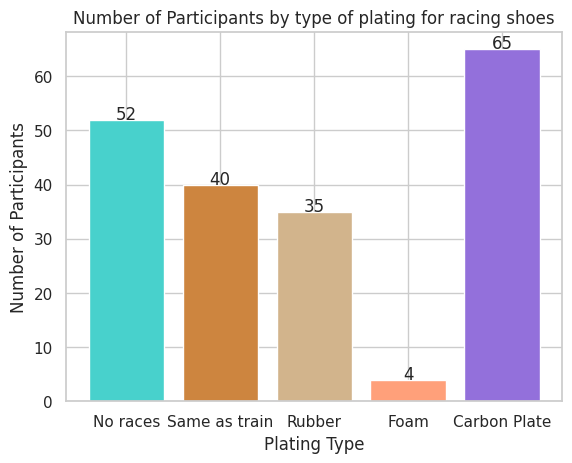

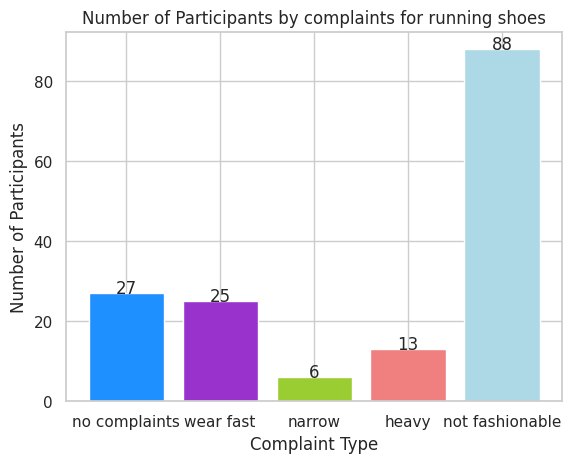

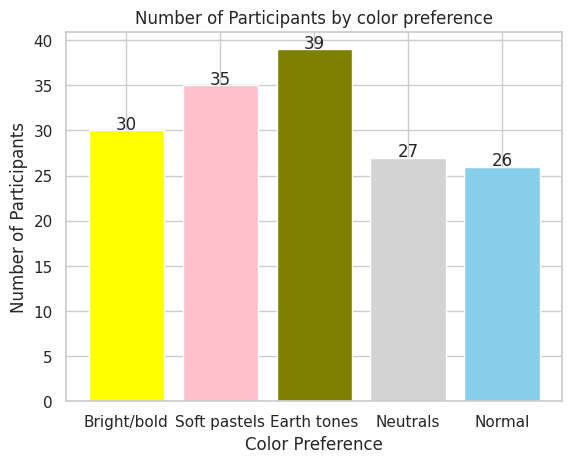

In [56]:
## Visualization by type of cushion
counts = df_new[['Q3r1',	'Q3r2',	'Q3r3',	'Q3r4']].sum()
# creating a bar plot with the counts
colors = ['orchid',  'lightsteelblue','orange','darkkhaki' ]
plt.bar(range(len(counts)), counts.values, color=colors )

# Changing axis
plt.xticks(range(len(counts)), ['Not sure','Foam','Rubber','Foam & rubber'])

# adding labels to the plot
plt.title('Number of Participants by type of cushion for training')
plt.xlabel('Cushion Type')
plt.ylabel('Number of Participants')


# adding total counts for each bar on the plot
for i, v in enumerate(counts.values):
    plt.text(i, v+0.1, str(v), ha='center')

# showing the plot
plt.show()


## Visualization by type of plating of race shoes
counts = df_new[['Q4r1',	'Q4r2',	'Q4r3',	'Q4r4', 'Q5r4']].sum()
# creating a bar plot with the counts
colors = ['mediumturquoise',  'peru','tan', 'lightsalmon', 'mediumpurple']
plt.bar(range(len(counts)), counts.values, color=colors )

# Changing axis
plt.xticks(range(len(counts)), ['No races','Same as train','Rubber','Foam', 'Carbon Plate'])

# adding labels to the plot
plt.title('Number of Participants by type of plating for racing shoes')
plt.xlabel('Plating Type')
plt.ylabel('Number of Participants')


# adding total counts for each bar on the plot
for i, v in enumerate(counts.values):
    plt.text(i, v+0.1, str(v), ha='center')

# showing the plot
plt.show()



## Visualization by complaints
counts = df_new[['Q6r1'	,'Q6r2','Q6r3'	,'Q6r4','Q6r5']].sum()
# creating a bar plot with the counts
colors = ['dodgerblue',  'darkorchid','yellowgreen', 'lightcoral', 'lightblue']
plt.bar(range(len(counts)), counts.values, color=colors)

# Changing axis
plt.xticks(range(len(counts)), ['no complaints',	 'wear fast',	'narrow',	'heavy'	,'not fashionable'])

# adding labels to the plot
plt.title('Number of Participants by complaints for running shoes')
plt.xlabel('Complaint Type')
plt.ylabel('Number of Participants')


# adding total counts for each bar on the plot
for i, v in enumerate(counts.values):
    plt.text(i, v+0.1, str(v), ha='center')

# showing the plot
plt.show()


## Visualization by color preference
counts = df_new[['Q7r1'	,'Q7r2','Q7r3'	,'Q7r4','Q7r5']].sum()
# creating a bar plot with the counts
colors = ['yellow',  'pink','olive', 'lightgray', 'skyblue']
plt.bar(range(len(counts)), counts.values, color=colors)

# Changing axis
plt.xticks(range(len(counts)), ['Bright/bold',	 'Soft pastels',	'Earth tones',	'Neutrals'	,'Normal'])

# adding labels to the plot
plt.title('Number of Participants by color preference')
plt.xlabel('Color Preference')
plt.ylabel('Number of Participants')


# adding total counts for each bar on the plot
for i, v in enumerate(counts.values):
    plt.text(i, v+0.1, str(v), ha='center')

# showing the plot
plt.show()

**Observations:**

- For their training shoes, 69 participants use rubber cushion. Similarly, 53 participants are not sure about their type of cushion.  Only 26 and 3 have foam and a combination of foam and rubber, respectively. 
- A majority of participants have carbon plate on their plating for their racing shoes. 52 participants say they don't run races while 40 use the same shoes that they train with. 35 participants use rubber while 4 use foam. 
- Out of the 149 participants, more than half think that their running shoes are not fashionable while 25 think they wear out too fast. 6 participants think they are narrow and 13 heavy. Only 27 participants have no complaints.
- There are three main categories that dominate color preference. 104 participants want runnning shoes with bright and bold colors, soft pastels like pink, coral or purple and earth notes like green, yellows and browns. Only 53 people want neutrals like black and white and/or something normal with no strong preference. 


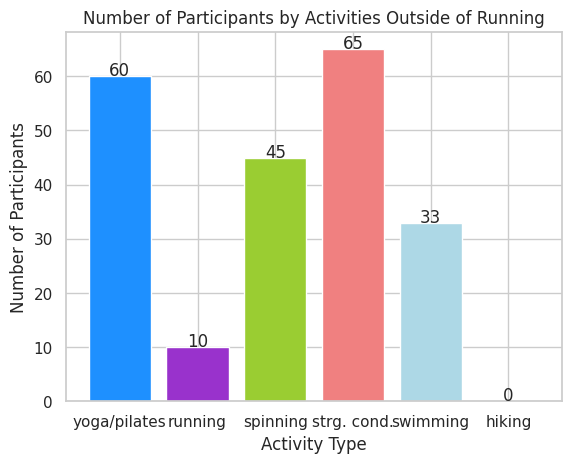

In [57]:
counts = df_new[['Q5r1',	'Q5r2',	'Q5r3',	'Q5r4',	'Q5r5',	'Q5r6']].sum()
# creating a bar plot with the counts
colors = ['dodgerblue',  'darkorchid','yellowgreen', 'lightcoral', 'lightblue']
plt.bar(range(len(counts)), counts.values, color=colors)

# Changing axis
plt.xticks(range(len(counts)), ['yoga/pilates',	'running',	'spinning'	,'strg. cond.',	'swimming'	,'hiking'])

# adding labels to the plot
plt.title('Number of Participants by Activities Outside of Running')
plt.xlabel('Activity Type')
plt.ylabel('Number of Participants')


# adding total counts for each bar on the plot
for i, v in enumerate(counts.values):
    plt.text(i, v+0.1, str(v), ha='center')

# showing the plot
plt.show()

**Observations:** 
- More than half of participants enjoy strenght conditioning like lifting, yoga and pilates. Zero people enjoy hiking while 10 only enjoy running. Around 45 enjoy spinning while 33 enjoy swimming. 

## Similarity Metric & Matrix

In [58]:
# Convert data frame to numpy array
X = df_new.values

# Calculate Jaccard similarity matrix
similarity_matrix = 1 - pairwise_distances(X, metric='jaccard')

In [59]:
similarity_matrix

array([[1.        , 0.33333333, 0.08333333, ..., 0.13043478, 0.14285714,
        0.04      ],
       [0.33333333, 1.        , 0.33333333, ..., 0.14285714, 0.29411765,
        0.26315789],
       [0.08333333, 0.33333333, 1.        , ..., 0.36842105, 0.6       ,
        0.73333333],
       ...,
       [0.13043478, 0.14285714, 0.36842105, ..., 1.        , 0.33333333,
        0.44444444],
       [0.14285714, 0.29411765, 0.6       , ..., 0.33333333, 1.        ,
        0.41176471],
       [0.04      , 0.26315789, 0.73333333, ..., 0.44444444, 0.41176471,
        1.        ]])

**Observations:** 
- This similarity matrix contains the similarity coefficients between all pairs of rows on this data set. The Jaccard similarity coefficient was used because it would show the value of each element in the matrix with a value between 0 and 1, where zero means the two rows have no common values and 1 means the two rows have exactly the same values.

# Clustering

## For this analysis, we will not do clustering on the Country and would rather try to understand the variation of other factors with  Country across groups like female vs male, age groups, etc. with respect to the cluster groups formed.

###  Preparing data for modeling

We will drop the countries columns as well as the validations columns for clustering: "S1r1","S1r2","S1r3", "S2r1","S2r2"

In [60]:
#Creating a data frame that includes the countries but excludes the validation columns: S2r1 and S2r2
data = df.copy(deep=True)
data=data[data['S2r2']!=1]
data = data.drop(columns=["S2r1","S2r2"])

#Creating a data frame that excludes the countries as well as validation columns (S2r1 and S2r2)
df_new = df_new.drop(columns=["S1r1","S1r2","S1r3", "S2r1","S2r2" ])

### K-Means Clustering

After some iterations with other cluster methods, K-Means provided better insights overall.

In [61]:
#Creating copy of the data to store labels from each algorithm
df_new_copy = df_new.copy(deep=True)

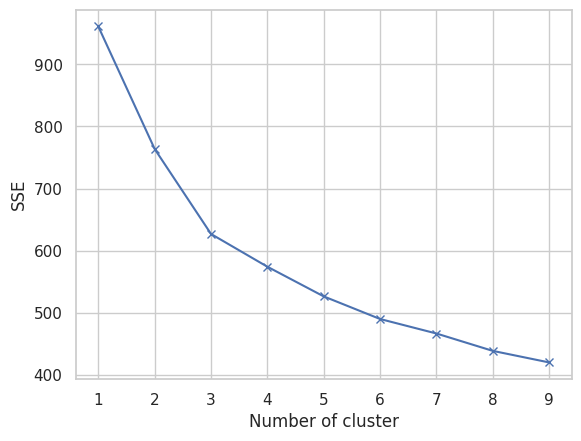

In [62]:
#Empty dictionary to store the SSE for each value of k
sse = {} 

# iterate for a range of Ks and fit the scaled data to the algorithm. Use inertia attribute from the clustering object and 
# store the inertia value for that k 
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=1).fit(df_new)
    sse[k] = kmeans.inertia_ 

#Elbow plot
plt.figure()
plt.plot(list(sse.keys()), list(sse.values()), 'bx-')
plt.xlabel("Number of cluster")
plt.ylabel("SSE")
plt.show()

**Observations:**

- We can see from the plot that there is a consistent dip from 2 to 9 but doesn't look clear the optimal number of cluster to chose. 

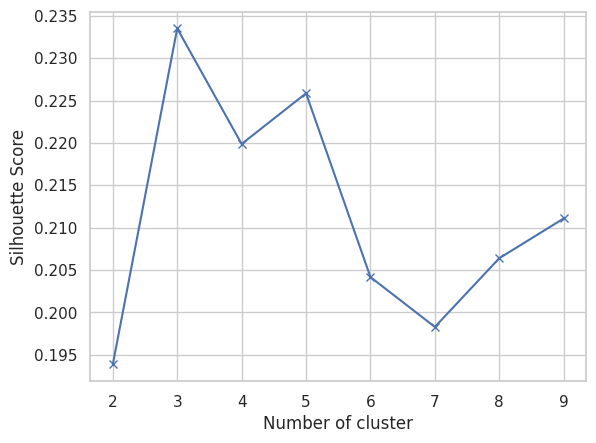

In [63]:
### Second opinion
#Empty dictionary to store the Silhouette score for each value of k
sc = {} 

# iterate for a range of Ks and fit the scaled data to the algorithm. Store the Silhouette score for that k 
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=1).fit(df_new)
    labels = kmeans.predict(df_new)
    sc[k] = silhouette_score(df_new, labels)

#Elbow plot
plt.figure()
plt.plot(list(sc.keys()), list(sc.values()), 'bx-')
plt.xlabel("Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

**Observations:**
 
-  The plot with Silhouette scores shows k=3 since that's the highest value.
- This value will be used for our KMeans clustering.

In [64]:
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(df_new)

#Adding predicted labels to the original data and scaled data 
df_new_copy['KMeans_Labels'] = kmeans.predict(df_new)
data['KMeans_Labels'] = kmeans.predict(df_new)
data['KMeans_Labels'].value_counts()

0    53
1    50
2    46
Name: KMeans_Labels, dtype: int64

**Observations:**
 
-  Each groups has a similar number of observations which shows a good distribution.
- Cluster 0 has the highest number, followed by cluster 1 and lastly cluster 2.

### Clustering Per Region

The following analysis is a deep dive into what is driving cluster groups for the USA, UK and Japan from a female and male perspective for the different questions asked on the survey

Visualizing groups
 - Even though each group had a similar number of observations, we will visualize these groups based on the country. 
 - Markets can differ greatly due to cultural diversity as well as geological location. Therefore, it was decided to look at each cluster based on country.  
 - Equally important, the country where these participants are from can shed light into running habits as perhaps some countries can be colder than others. 


In [66]:
# create a new data frame for participants from the USA only
usa_df = data[data['S1r1'] == 1]
# create a new data frame for participants from the UK only
uk_df = data[data['S1r2'] == 1]
# create a new data frame for participants from Japan only
j_df = data[data['S1r3'] == 1]

In [68]:
# create a new data frame for participants from the USA only and cluster=0 1 and 2
usa_df_0 = usa_df[usa_df['KMeans_Labels'] == 0]
usa_df_1 = usa_df[usa_df['KMeans_Labels'] == 1]
usa_df_2 = usa_df[usa_df['KMeans_Labels'] == 2]

# create a new data frame for participants from the UK only and cluster=0 1 and 2
uk_df_0 = uk_df[uk_df['KMeans_Labels'] == 0]
uk_df_1 = uk_df[uk_df['KMeans_Labels'] == 1]
uk_df_2 = uk_df[uk_df['KMeans_Labels'] == 2]

# create a new data frame for participants from Japan only and cluster=0 1 and 2
j_df_0 = j_df[j_df['KMeans_Labels'] == 0]
j_df_1 = j_df[j_df['KMeans_Labels'] == 1]
j_df_2 = j_df[j_df['KMeans_Labels'] == 2]


## USA Participants

### Participant Age

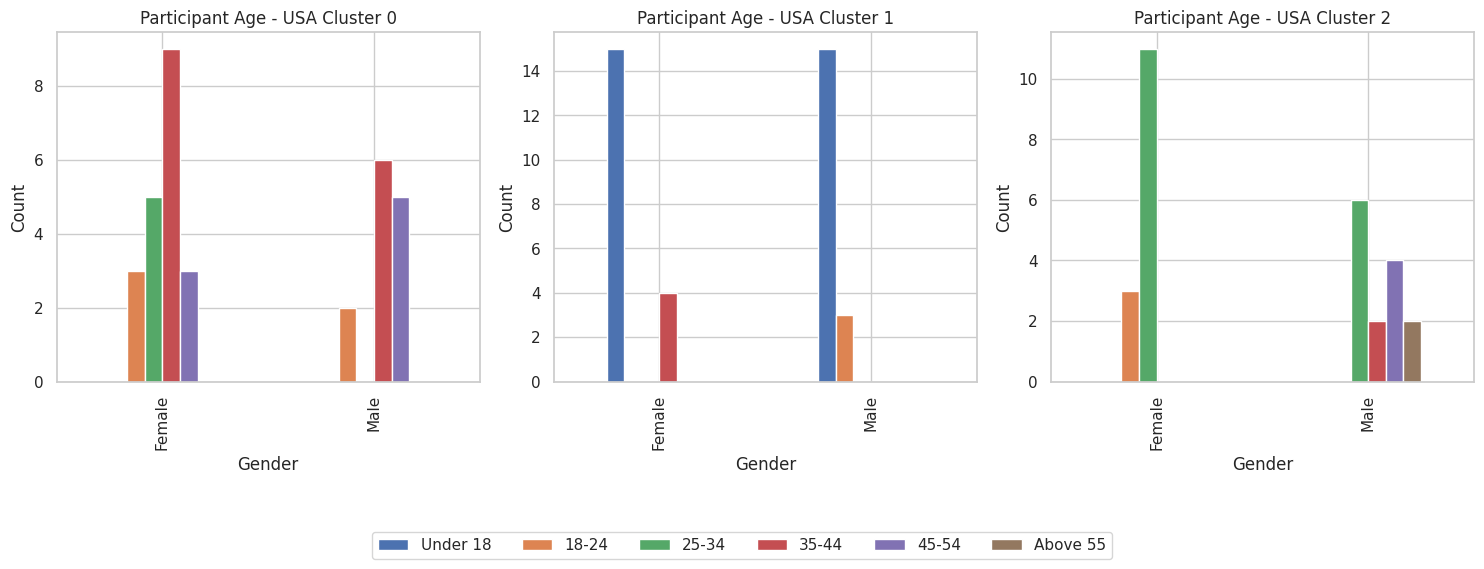

In [69]:
# create a list of the data frames
df_age = [usa_df_0, usa_df_1, usa_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_age):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['S4r1'] == 1) | (df['S4r2'] == 1) | (df['S4r3'] == 1) | (df['S4r4'] == 1) | (df['S4r5'] == 1) | (df['S4r6'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['S4r1'	,'S4r2'	,'S4r3'	,'S4r4'	,'S4r5'	,'S4r6'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'S4r1': 'Under 18', 'S4r2': '18-24', 'S4r3': '25-34', 'S4r4': '35-44', 'S4r5': '45-54','S4r6': 'Above 55'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Participant Age - USA Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Looking at the participants from the USA, cluster 0 seems to have more females and males on the 35-44 years old category. 
- Cluster 1 seems to have more females and males under 18 years old. 
- Cluster 2 seems to have more females and males on the 25-34 years old category.


### How regularly do you go for a run?

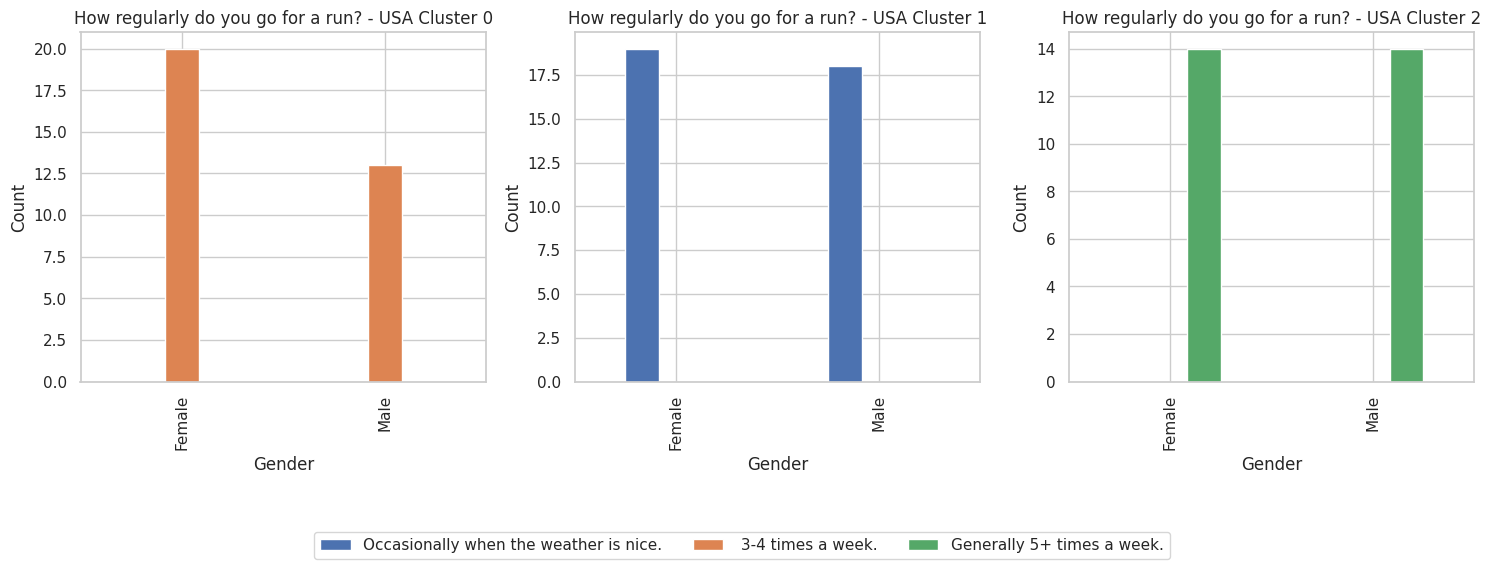

In [70]:
# create a list of the data frames
df_run = [usa_df_0, usa_df_1, usa_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_run):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q1r1'] == 1) | (df['Q1r2'] == 1) | (df['Q1r3'] == 1) ]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q1r1',	'Q1r2',	'Q1r3'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q1r1': 'Occasionally when the weather is nice.', 'Q1r2': ' 3-4 times a week.', 'Q1r3': 'Generally 5+ times a week.'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('How regularly do you go for a run? - USA Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Looking at the participants from USA, cluster 0 is solely dedicated to females and males that go on runs 3-4 times a week. 
- Cluster 1 only has participants female and male that go occasionally when the weather is nice.
- Cluster 2 has participants female and male where they generally go for a run 5+ times a week. 
- Clusters 0 and 2 are perhaps the most market targetable groups since they would generally spend more time running and therefore would need to buy running shoes more often.
- Lastly, Cluster 1 would be the least targetable group since they only go for runs occasionally.
- Responses about how often they go for runs is mainly driving how these clusters were generated. From a marketing point of view, it makes sense to separate your users by how often they use your product as each group will have different needs. 

### How many pairs of running shoes do you own at a time when you train?

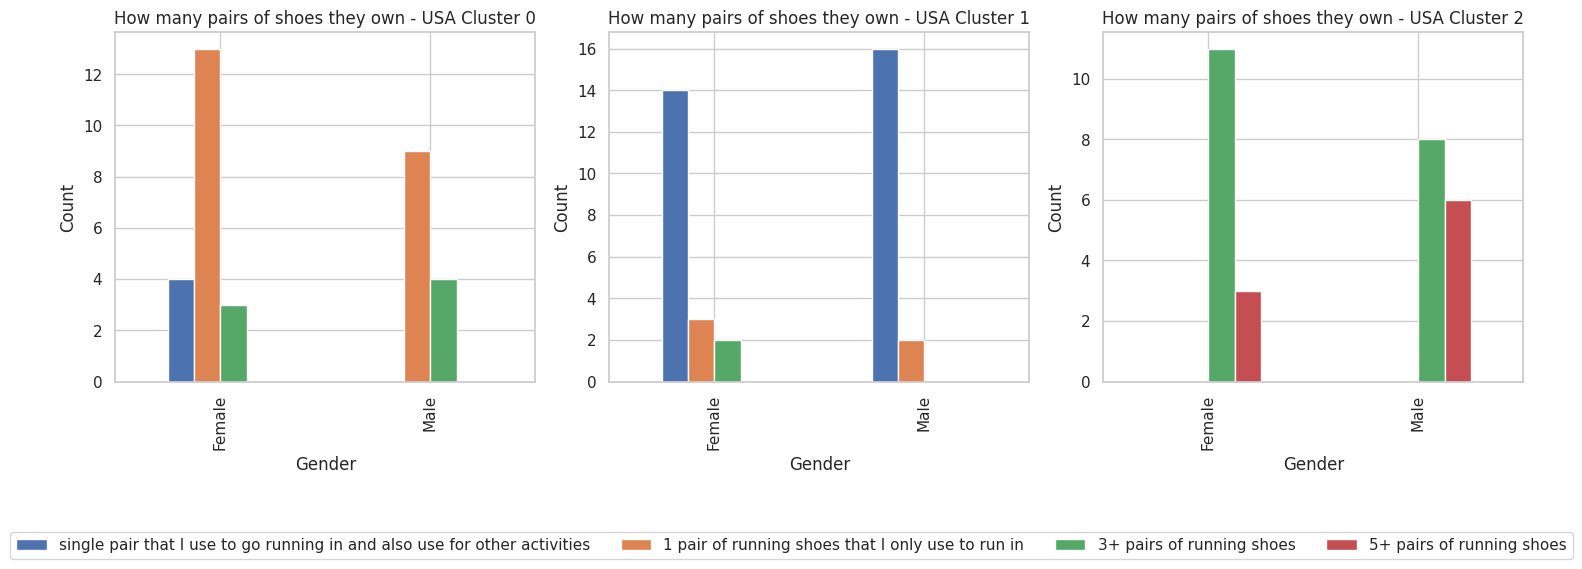

In [71]:
# create a list of the data frames
df_pairs = [usa_df_0, usa_df_1, usa_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_pairs):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q2r1'] == 1) | (df['Q2r2'] == 1) | (df['Q2r3'] == 1)  | (df['Q2r4'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q2r1',	'Q2r2',	'Q2r3', 'Q2r4'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q2r1': 'single pair that I use to go running in and also use for other activities', 'Q2r2': '1 pair of running shoes that I only use to run in', 'Q2r3': '3+ pairs of running shoes', 'Q2r4': '5+ pairs of running shoes'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('How many pairs of shoes they own - USA Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Based on observations about how many pairs they own, it makes sense that cluster 2 contains mostly participants that own more than 3 pairs of running shoes as they go for runs more than 5 times a week.
- This is followed by cluster 0 which mostly has participants that own 1 pair of running shoes used to run and own 3+ (but less than 5) running shoes.
- Cluster 1 is mostly participants that own a single pair that are used for running but also for other activities.

### What type of cushioning do the shoes that you train in most regularly use?

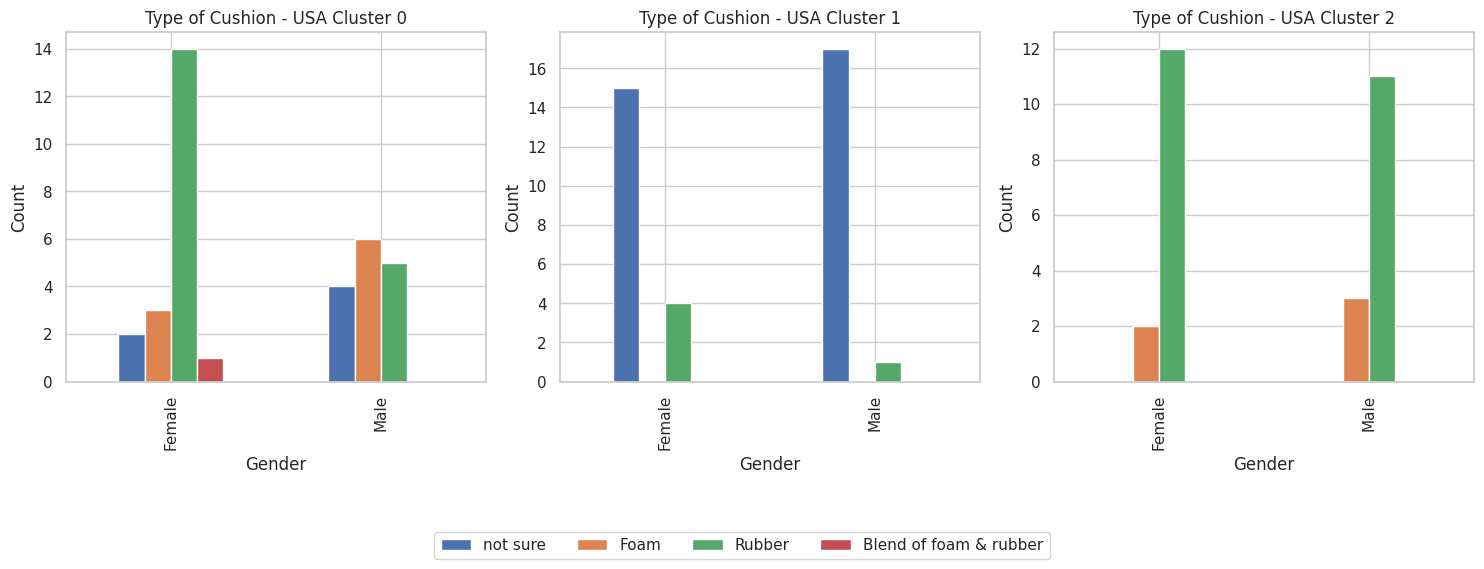

In [72]:
# create a list of the data frames
df_cushion = [usa_df_0, usa_df_1, usa_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_cushion):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q3r1'] == 1) | (df['Q3r2'] == 1) | (df['Q3r3'] == 1)  | (df['Q3r4'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q3r1',	'Q3r2',	'Q3r3', 'Q3r4'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q3r1': 'not sure', 'Q3r2': 'Foam', 'Q3r3': 'Rubber', 'Q3r4': 'Blend of foam & rubber'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Type of Cushion - USA Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Based on these observations, cluster 2 participants (and the group that runs and owns more running shoes) use rubber cushioning. Cluster 2 also has the same number of males and females for each category.
- Most of cluster 0 has a combination between foam or rubber. A small number are unsure about their cushion material.
- On the other hand, a majority of cluster 1 don't know their cushion material. This makes sense as this cluster group only owns a single pair that they use for running and other activities.

### What type of plating do the shoes that you race in use?

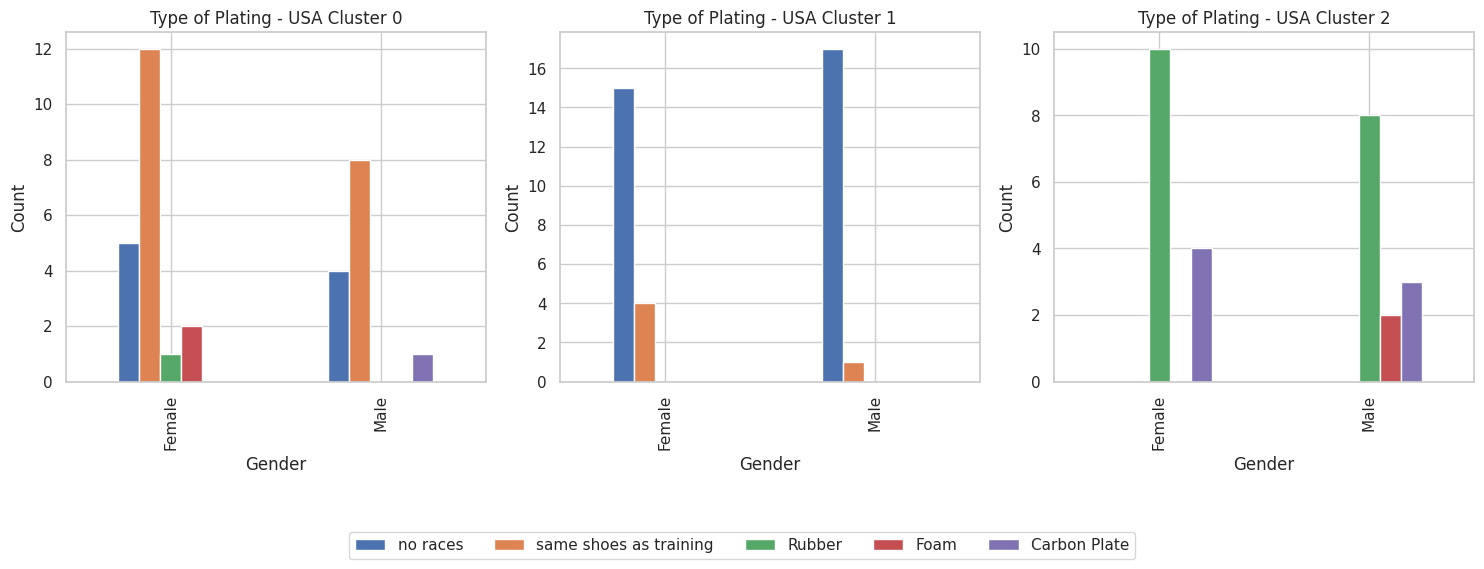

In [73]:
# create a list of the data frames
df_plat = [usa_df_0, usa_df_1, usa_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_plat):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q4r1'] == 1) | (df['Q4r2'] == 1) | (df['Q4r3'] == 1)  | (df['Q4r4'] == 1) | (df['Q4r5'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q4r1',	'Q4r2',	'Q4r3', 'Q4r4', 'Q4r5'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q4r1': 'no races', 'Q4r2': 'same shoes as training', 'Q4r3': 'Rubber', 'Q4r4': 'Foam', 'Q4r5': 'Carbon Plate'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Type of Plating - USA Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Similar observations to cushion type are observed for plating. Cluster 2 participants (and the group that runs and owns more running shoes) use rubber plating, follow by carbon plate. Cluster 2 also has almost same number of males and females for each category.
- Most of cluster 0 mostly has participants where they use the same shoes as with the ones that they train with for their races. A majority of those participants are female. 
- On the other hand, a majority of cluster 1 say they don't race and therefore don't have racing shoes with almost equal distribution between females and males.

### What colors do you prefer for the shoes you run in most often?

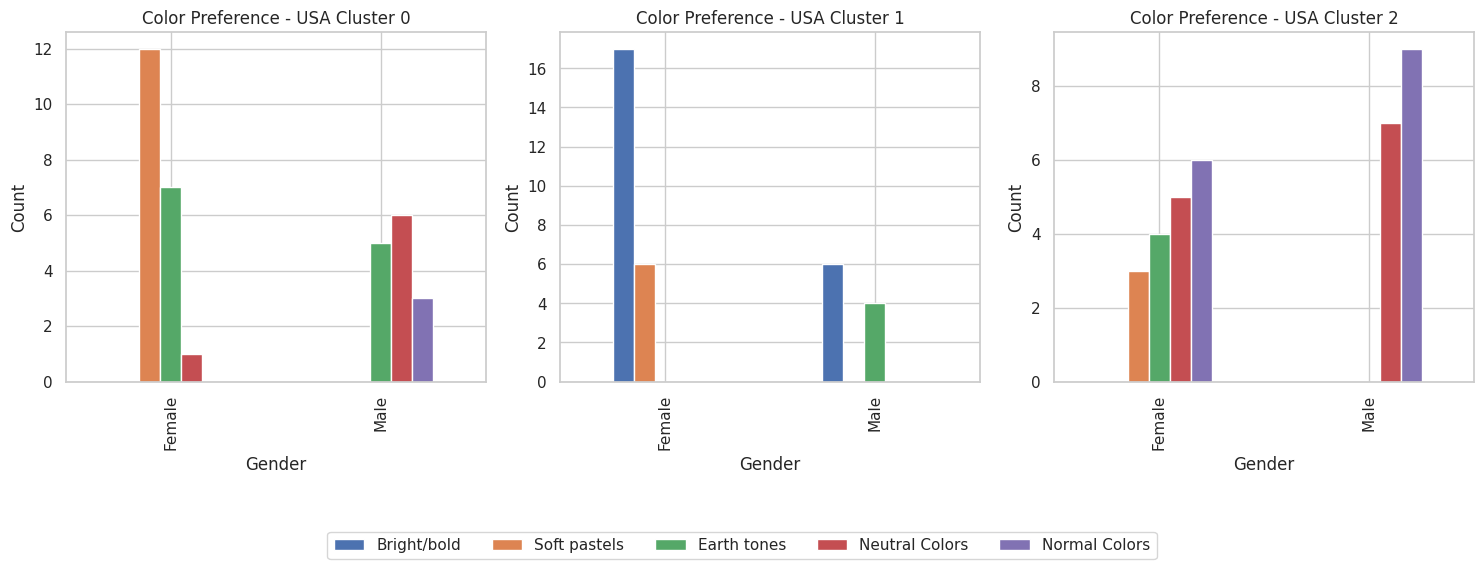

In [24]:
# create a list of the data frames
df_list = [usa_df_0, usa_df_1, usa_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_list):
    # create a new data frame that filters only the rows where Q6r1, Q6r2, Q6r3, Q6r4, or Q6r5 are 1s
    df_filtered = df[(df['Q7r1'] == 1) | (df['Q7r2'] == 1) | (df['Q7r3'] == 1) | (df['Q7r4'] == 1) | (df['Q7r5'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q7r1', 'Q7r2', 'Q7r3', 'Q7r4', 'Q7r5'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q7r1': 'Bright/bold', 'Q7r2': 'Soft pastels', 'Q7r3': 'Earth tones', 'Q7r4': 'Neutral Colors', 'Q7r5': 'Normal Colors'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Color Preference - USA Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()

 **Observations:** 
- Looking at the participants from the USA, cluster 0 seems to have more females that want soft pastels colors.
- Cluster 1 is dominated by females that want bright/bold colors.
- Females on cluster 2 have a very diverse color selection between soft pastels, earth tones, neutral colors as well as normal colors. Males on the other hand prefer neutral and normal colors. 

### What physical activities do you do outside of running?

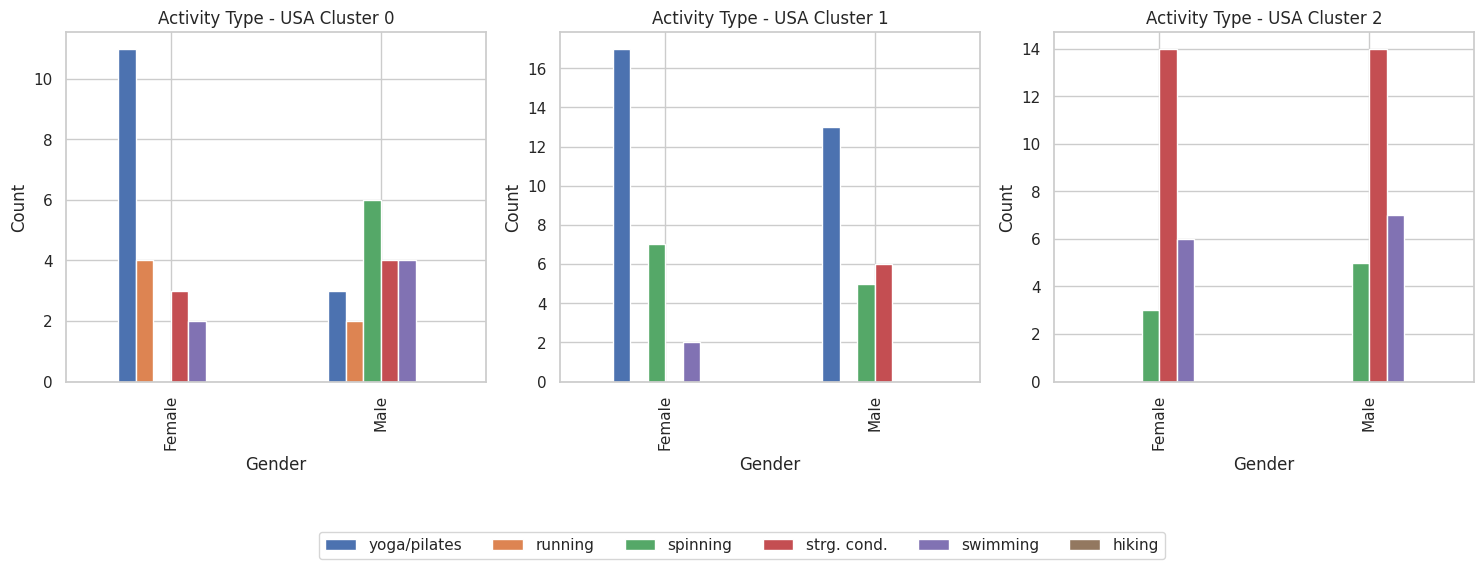

In [22]:
# create a list of the data frames
df_act = [usa_df_0, usa_df_1, usa_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_act):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q5r1'] == 1) | (df['Q5r2'] == 1) | (df['Q5r3'] == 1)  | (df['Q5r4'] == 1) | (df['Q5r5'] == 1)| (df['Q5r6'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q5r1',	'Q5r2',	'Q5r3', 'Q5r4', 'Q5r5', 'Q5r6'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q5r1': 'yoga/pilates', 'Q5r2': 'running', 'Q5r3': 'spinning', 'Q5r4': 'strg. cond.', 'Q5r5': 'swimming','Q5r6': 'hiking'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Activity Type - USA Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()

 **Observations:** 
- Looking at the participants from the USA, cluster 0 seems to have more females that do yoga/pilates. Males have some diversity between running, spinning, strenght conditioning and swimming. 
- Cluster 1 has around the same number of females and males that do yoga/pilates
- Females and males on cluster 2 enjoy strenght conditioning more than any other activity.

### What is your top complaint about the shoe you use to run in most regularly?

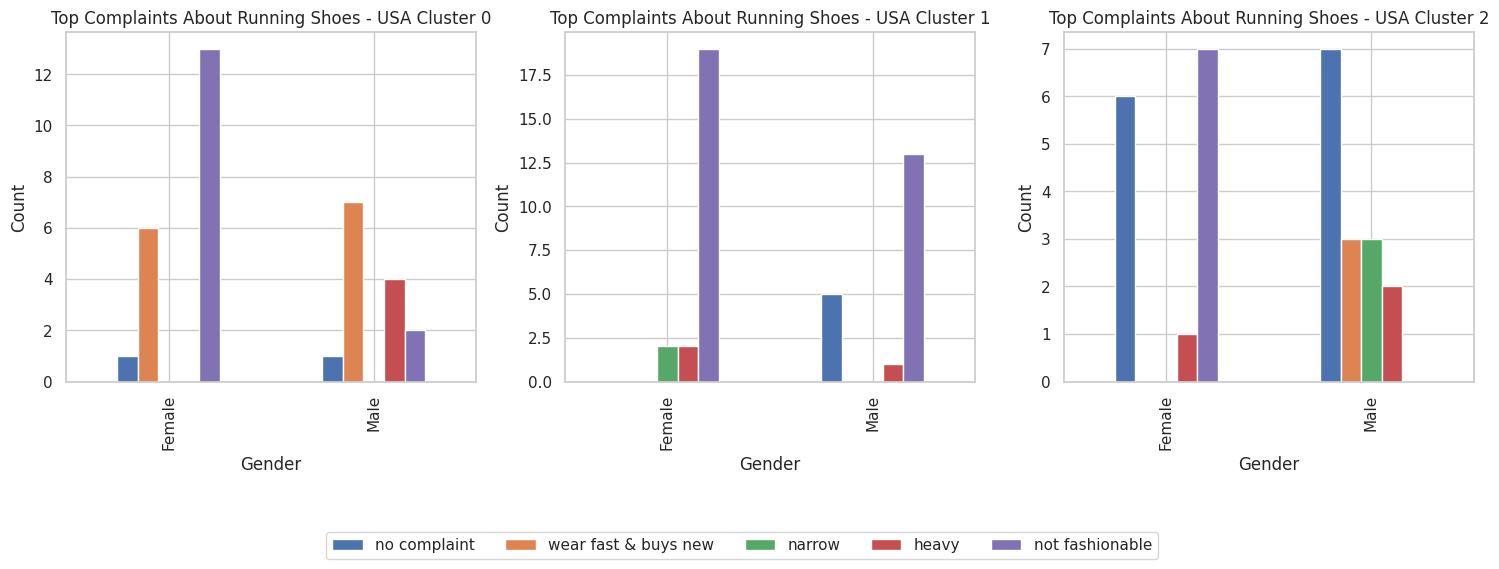

In [ ]:
#Top complaints
# create a list of the data frames
df_list = [usa_df_0, usa_df_1, usa_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_list):
    # create a new data frame that filters only the rows where Q6r1, Q6r2, Q6r3, Q6r4, or Q6r5 are 1s
    df_filtered = df[(df['Q6r1'] == 1) | (df['Q6r2'] == 1) | (df['Q6r3'] == 1) | (df['Q6r4'] == 1) | (df['Q6r5'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q6r1', 'Q6r2', 'Q6r3', 'Q6r4', 'Q6r5'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q6r1': 'no complaint', 'Q6r2': 'wear fast & buys new', 'Q6r3': 'narrow', 'Q6r4': 'heavy', 'Q6r5': 'not fashionable'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Top Complaints About Running Shoes - USA Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Looking at the participants from the USA, cluster 0 seems to have more females that complaint about running shows not being fashionable. 
- Cluster 1 seems to have a similar number of participants agreeing on shoes not being fashionable enough. 
- Cluster 2 seems to be dominated by females and males that have no complaints about their running shoes but also includes a majority of women thinking their running shoes are not fashionable.

### Final Recommendations for participants in the USA

We would like to base our recommendations based off the observations per each cluster group in the USA.

Starting with the group with more market opportunity: 

Cluster 0:
1. This group has a very diverse age distribution specially for females. They range from ages between 18 to 54 years old. There are no participants that are under 18. At this age, one can assume they are more active physically but also are more financially stable. They also go for runs 3-4 times a week which may mean they'll be purchasing running shoes more often. This is backed up by the observation that they only own only one pair of running shoes. One of the complaints from this group is that their running shoes are not fashionable, specially for females. For males, their main complaint is that they wear out too fast and have the need to buy new ones. Overall, this group can be targeted by making more fashionable and more resistant to wear running shoes. Females would prefer soft pastels whereas males would prefer neutral tones. This can potentially incentivize them to own more than one pair of runnign shoes. 


Cluster 2:
1. This group has less diversity in age distribution. Females are between 18-34 years old while males are from 25 to 54 with 2 participants being above 55 years old. Similar to cluster 0,there are no participants that are under 18. At this age one can assume they are physically active and financially stable. This is backed up by the observation that they generally go for runs more than 5 times a week and owm more than 5 pair of running shoes. One of the complaints from this group is that their running shoes are not fashionable, specially for females.  For males, there is a significant number of participants that have no complaints. However, there are a few that complaint about wearing out too fast, narrow and heavy. Females and males from this group would for the most part prefer normal colors. Overall, this group can be targeted by making more fashionable, more resistant and less narrow/heavy running shoes. We can determine that this group is an already stablished customer as they are the ones that run the most from these three cluster groups. They are perhaps the most knowlegeable in terms of running shoes in the market and it may indicate why they are the group with most participants indicating they have no complaints.


Cluster 1:
1. This group is mostly dominated by participants under 18 years old with two participants being 18-24 and four being between 35 and 44 years old. At this age, one can assume, they are not necesarily in a stable financial situation. One main observation from this group is that they generally go for runs ocassionally when the weather is nice and usually own one single pair that is used for running and other activities. One of the complaints from this group is that their running shoes are not fashionable, specially for females. In similar numbers, males complaint about this same reason. Overall, this group can be targeted by making more fashonable shoes for females and males. Females from this group would prefer bright/bold colors while male would prefer earth tones but also bright/bold colors. 

## UK

### Participant Age

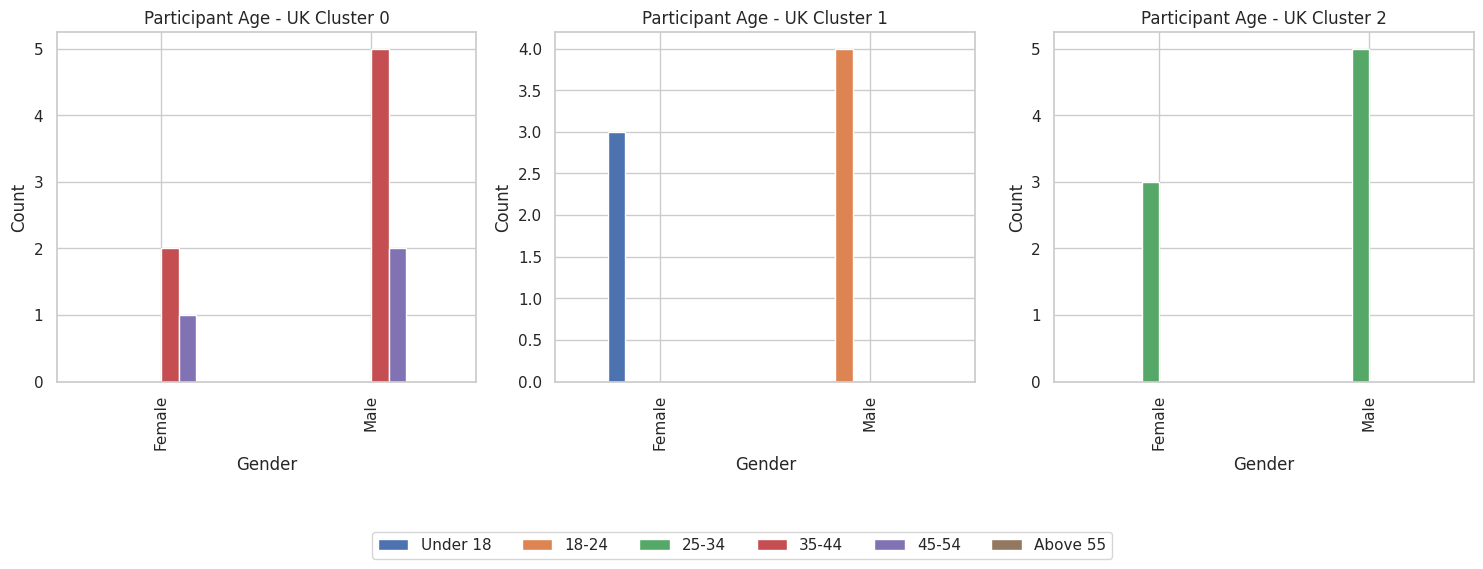

In [ ]:
# create a list of the data frames
df_age = [uk_df_0, uk_df_1, uk_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_age):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['S4r1'] == 1) | (df['S4r2'] == 1) | (df['S4r3'] == 1) | (df['S4r4'] == 1) | (df['S4r5'] == 1) | (df['S4r6'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['S4r1'	,'S4r2'	,'S4r3'	,'S4r4'	,'S4r5'	,'S4r6'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'S4r1': 'Under 18', 'S4r2': '18-24', 'S4r3': '25-34', 'S4r4': '35-44', 'S4r5': '45-54','S4r6': 'Above 55'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Participant Age - UK Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Looking at the participants from the UK, cluster 0 seems to have more females and males on the 35-44 years old category. 
- Cluster 1 seems to have just females from the under 18 category and only males from 18-24 years old.
- Cluster 2 seems to have only females and males on the 25-34 years old category. This is similar grouping seeing on the USA.
- It's worth noting the UK didn't have participants that were 55 years or older.

### How regularly do you go for a run?

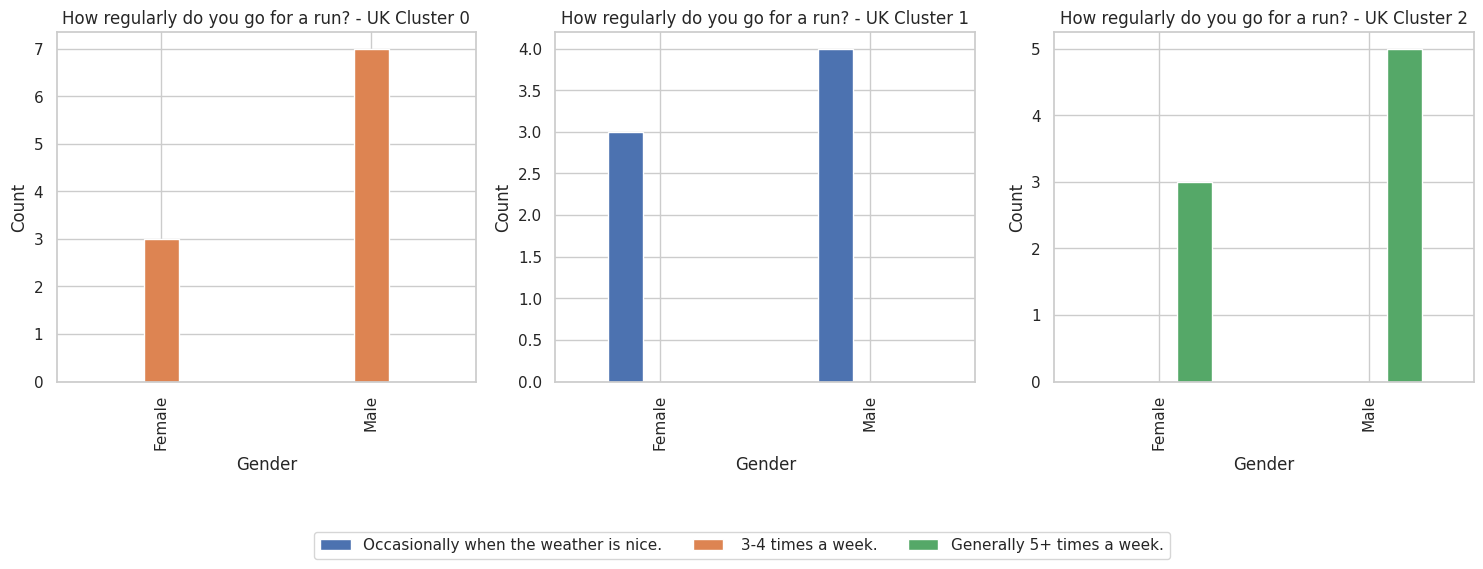

In [ ]:
# create a list of the data frames
df_run = [uk_df_0, uk_df_1, uk_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_run):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q1r1'] == 1) | (df['Q1r2'] == 1) | (df['Q1r3'] == 1) ]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q1r1',	'Q1r2',	'Q1r3'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q1r1': 'Occasionally when the weather is nice.', 'Q1r2': ' 3-4 times a week.', 'Q1r3': 'Generally 5+ times a week.'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('How regularly do you go for a run? - UK Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
 Similar observations are derived from the UK.
- Looking at the participants from the UK, cluster 0 is solely dedicated to females and males that go on runs 3-4 times a week. 
- Cluster 1 only has participants female and male that go occasionally when the weather is nice.
- Cluster 2 has participants female and male where they generally gor for a run 5+ times a week. 
- As mentioned, cluster two would be the most targetable group followed by cluster 0 and then 1.

### How many pairs of running shoes do you own at a time when you train?

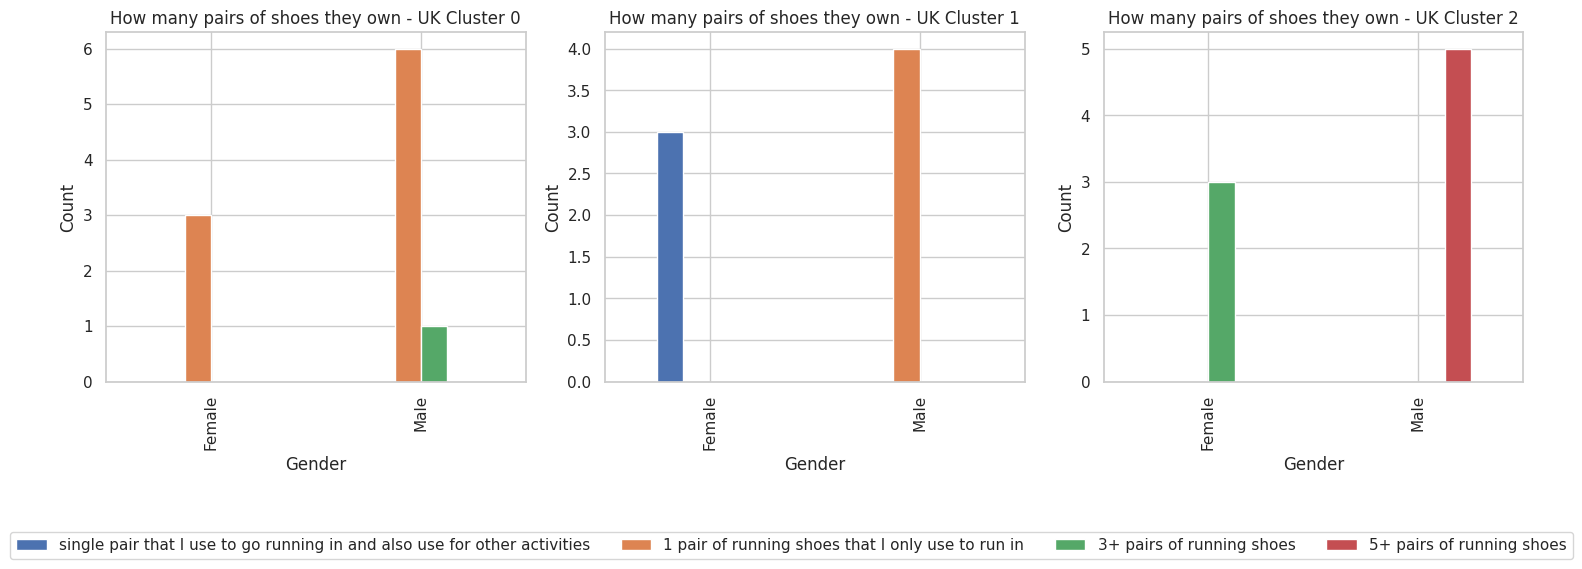

In [ ]:
# create a list of the data frames
df_pairs = [uk_df_0, uk_df_1, uk_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_pairs):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q2r1'] == 1) | (df['Q2r2'] == 1) | (df['Q2r3'] == 1)  | (df['Q2r4'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q2r1',	'Q2r2',	'Q2r3', 'Q2r4'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q2r1': 'single pair that I use to go running in and also use for other activities', 'Q2r2': '1 pair of running shoes that I only use to run in', 'Q2r3': '3+ pairs of running shoes', 'Q2r4': '5+ pairs of running shoes'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('How many pairs of shoes they own - UK Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Similar conclusions for each cluster from the USA are observed for participants from the UK. 
- Cluster 2 contains only participants that own more than 3 pairs of running shoes.
- This is followed by cluster 0 which mostly has participants that own 1 pair of running shoes used to run and one participant that owns 3+ (but less than 5) running shoes.
- Cluster 1 is mostly participants that own a single pair that are used for running but also for other activities for females and males owning one pair of shoes for running. 
- This conclusions suggest that males run more often as there are more males in all clusters combined owning more than 3 pairs of running shoes than there are women.

### What type of cushioning do the shoes that you train in most regularly use?

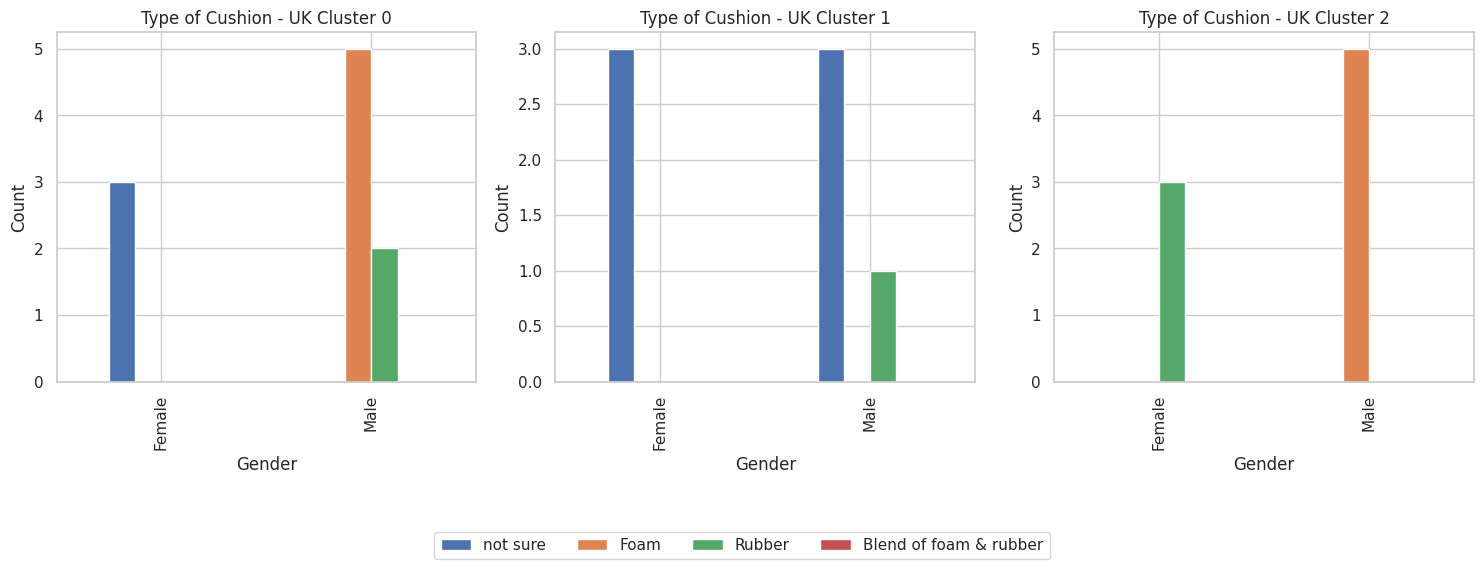

In [ ]:
# create a list of the data frames
df_cushion = [uk_df_0, uk_df_1, uk_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_cushion):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q3r1'] == 1) | (df['Q3r2'] == 1) | (df['Q3r3'] == 1)  | (df['Q3r4'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q3r1',	'Q3r2',	'Q3r3', 'Q3r4'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q3r1': 'not sure', 'Q3r2': 'Foam', 'Q3r3': 'Rubber', 'Q3r4': 'Blend of foam & rubber'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Type of Cushion - UK Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Based on these observations, males on cluster 2 participants (and the group that runs and owns more running shoes) use foam cushioning. While females use more rubber.
- Most of cluster 0 has a combination between not sure, foam or rubber.
- On the other hand, a majority of cluster 1 don't know their cushion material. This makes sense as this cluster group only owns a single pair that they use for running and other activities.

### What type of plating do the shoes that you race in use?

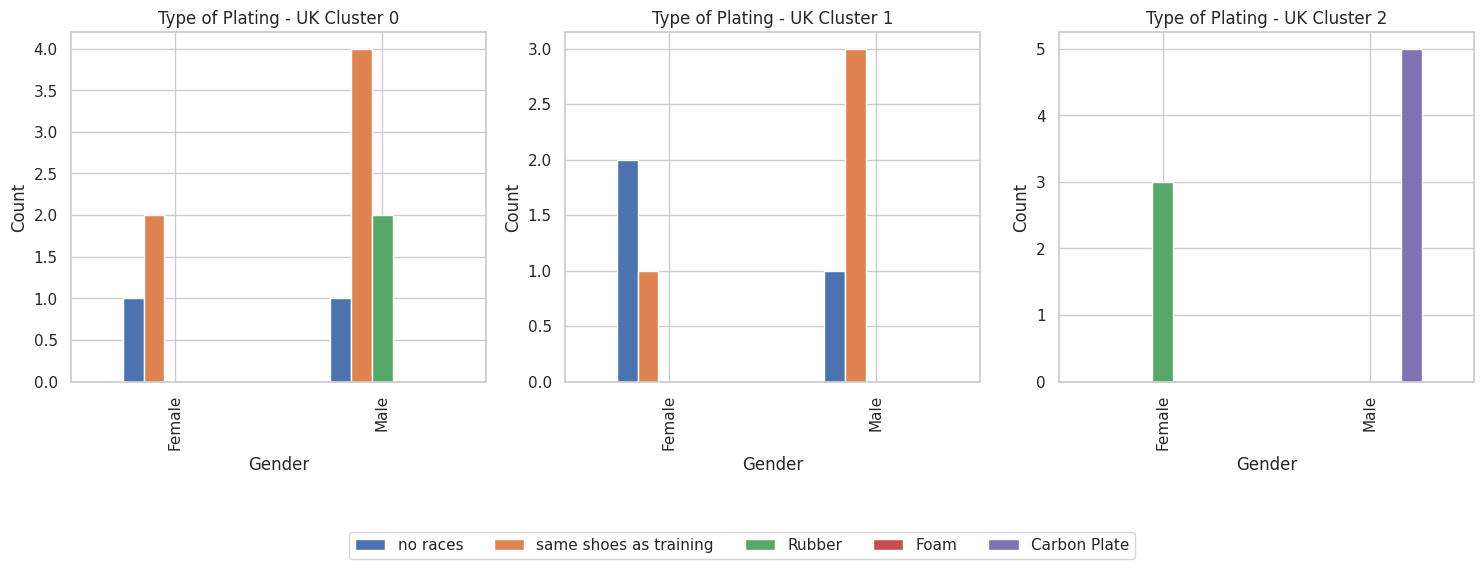

In [25]:
# create a list of the data frames
df_plat = [uk_df_0, uk_df_1, uk_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_plat):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q4r1'] == 1) | (df['Q4r2'] == 1) | (df['Q4r3'] == 1)  | (df['Q4r4'] == 1) | (df['Q4r5'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q4r1',	'Q4r2',	'Q4r3', 'Q4r4', 'Q4r5'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q4r1': 'no races', 'Q4r2': 'same shoes as training', 'Q4r3': 'Rubber', 'Q4r4': 'Foam', 'Q4r5': 'Carbon Plate'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Type of Plating - UK Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Males on cluster 2 participants (and the group that runs and owns more running shoes) use carbon plate, follow by women that use rubber. Cluster 2 also has more number of males than females.
- Most of cluster 0 mostly has participants where they use the same shoes as with the ones that they train with for their races. A majority of those participants are male, which is opposite to the USA findings. 
- On the other hand, a majority of cluster 1 say they use the same shoes as training for their racing.

### What physical activities do you do outside of running?

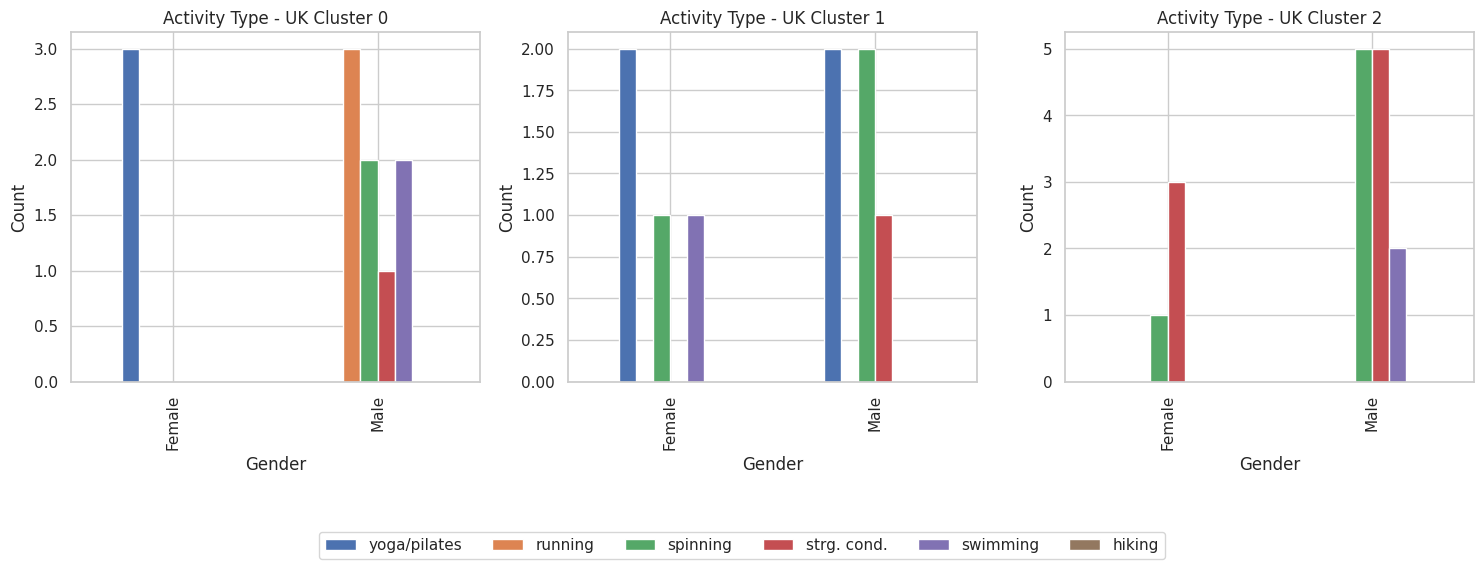

In [27]:
# create a list of the data frames
df_act = [uk_df_0, uk_df_1, uk_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_act):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q5r1'] == 1) | (df['Q5r2'] == 1) | (df['Q5r3'] == 1)  | (df['Q5r4'] == 1) | (df['Q5r5'] == 1)| (df['Q5r6'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q5r1',	'Q5r2',	'Q5r3', 'Q5r4', 'Q5r5', 'Q5r6'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q5r1': 'yoga/pilates', 'Q5r2': 'running', 'Q5r3': 'spinning', 'Q5r4': 'strg. cond.', 'Q5r5': 'swimming','Q5r6': 'hiking'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Activity Type - UK Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()

 **Observations:** 
- Similar to the USA, cluster 0 has more females that do yoga/pilates. Males have some diversity between running, spinning, strenght conditioning and swimming. 
- Cluster 1 has around the same number of females and males that do yoga/pilates.
- Females and males on cluster 2 enjoy strenght conditioning and spinning more than any other activity.

### What is your top complaint about the shoe you use to run in most regularly?

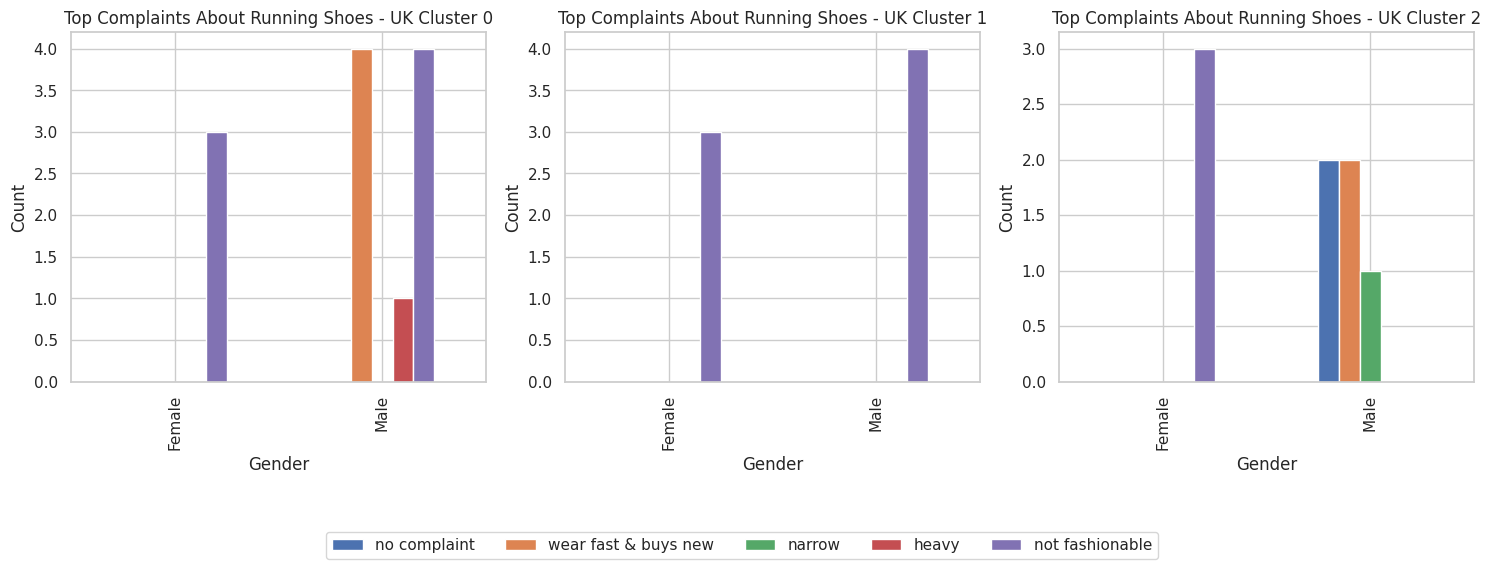

In [ ]:
# create a list of the data frames
df_list = [uk_df_0, uk_df_1, uk_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_list):
    # create a new data frame that filters only the rows where Q6r1, Q6r2, Q6r3, Q6r4, or Q6r5 are 1s
    df_filtered = df[(df['Q6r1'] == 1) | (df['Q6r2'] == 1) | (df['Q6r3'] == 1) | (df['Q6r4'] == 1) | (df['Q6r5'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q6r1', 'Q6r2', 'Q6r3', 'Q6r4', 'Q6r5'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q6r1': 'no complaint', 'Q6r2': 'wear fast & buys new', 'Q6r3': 'narrow', 'Q6r4': 'heavy', 'Q6r5': 'not fashionable'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Top Complaints About Running Shoes - UK Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Looking at the participants from the UK, cluster 0 seems to have more females that complaint about running shows not being fashionable. 
- Cluster 1 only has participants female and male agreeing on shoes not being fashionable enough 
- Cluster 2 seems to be dominated by males with complaints about narrow, wear out fast and no complaint. Whereas Females on this group only complaint about not being fashionable enough. 

### What colors do you prefer for the shoes you run in most often?

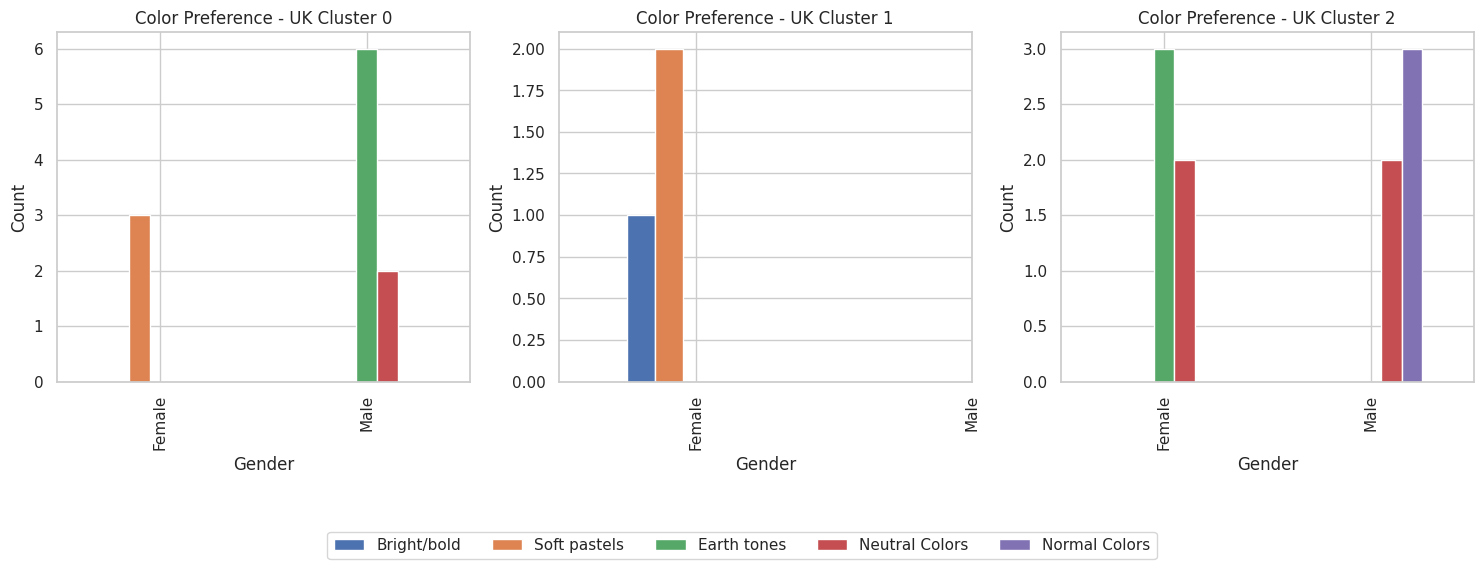

In [29]:
# create a list of the data frames
df_list = [uk_df_0, uk_df_1, uk_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_list):
    # create a new data frame that filters only the rows where Q6r1, Q6r2, Q6r3, Q6r4, or Q6r5 are 1s
    df_filtered = df[(df['Q7r1'] == 1) | (df['Q7r2'] == 1) | (df['Q7r3'] == 1) | (df['Q7r4'] == 1) | (df['Q7r5'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q7r1', 'Q7r2', 'Q7r3', 'Q7r4', 'Q7r5'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q7r1': 'Bright/bold', 'Q7r2': 'Soft pastels', 'Q7r3': 'Earth tones', 'Q7r4': 'Neutral Colors', 'Q7r5': 'Normal Colors'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Color Preference - UK Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()

 **Observations:** 
- Looking at the participants from the UK, cluster 0 seems to have more males that want earth tones and neutral colors.
- Cluster 1 is dominated by females that want soft pastels and bright/bold colors.
- Females on cluster 2 prefer neutral and earth tones whereas males also prefer neutral and normal colors.

### Final Recommendations for participants in the UK

We would like to based off our recommendations based of the observations per each cluster group in the UK.

Starting with the group with more market opportunity: 

Cluster 0:
1. This group has a binary age distribution for males and females. They range from ages between 35 to 54 years old. There are no participants that are under 18. At this age, one can assume they are more active physically but also are more financially stable. They also go for runs 3-4 times a week which may mean they'll be purchasing running shoes more often. This is backed up by the observation that they mostly own only one pair of running shoes and 1 participant owning 3+ (but less than 5) running shoes. One of the complaints from this group is that their running shoes are not fashionable, specially for females.  For males, their main complaint is that they wear out too fast and are heavy. Overall, this group can be targeted by making more fashonable and more resistant to wear running shoes. Females would prefer soft pastels whereas males would prefer earth tones. This can potentially incentivize them to own more than one pair of running shoes. 


Cluster 2:
1. This group is made by participants between age 25 to 34 years old. Similar to cluster 0,there are no participants that are under 18. At this age once can assume they are physically active and financially stable. This is backed up by the observation that they generally go for runs more than 5 times a week and owm more than 5 pair of running shoes. The only complaint from females is that their running shoes are not fashionable.  For males, there are a few that complaint about wearing out too fast, narrow and some with no complaints. Overall, this group can be targeted by making more fashionable, more resistant running shoes. We can determine that this group is an already stablished customer as they are the ones that run the most from these three cluster groups. They are perhaps the most knowlegeable in terms of running shoes in the market. However, this group didn't have participants that had no complaints. 

Cluster 1:
1. This group is mostly dominated by males between 18-24 years old and all females under 18 years old. At this age, one can assume, they are not necesarily in a stable financial situation. One main observation from this group is that they always go for runs ocassionally when the weather is nice and usually own one single pair that is used for running and other activities. The only complaint from this group is that their running shoes are not fashionable, for males and females. Overall, this group can be targeted by making more fashonable shoes for females and males. 


## Japan

### Participant Age

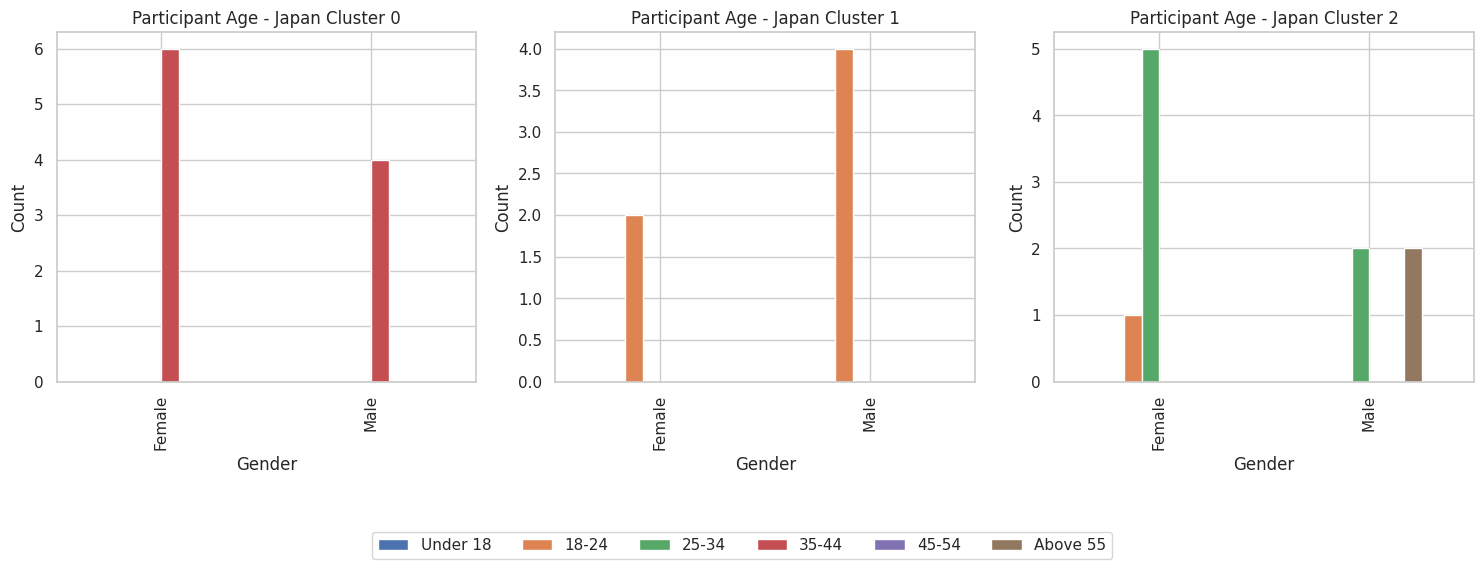

In [ ]:
# create a list of the data frames
df_age = [j_df_0, j_df_1, j_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_age):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['S4r1'] == 1) | (df['S4r2'] == 1) | (df['S4r3'] == 1) | (df['S4r4'] == 1) | (df['S4r5'] == 1) | (df['S4r6'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['S4r1'	,'S4r2'	,'S4r3'	,'S4r4'	,'S4r5'	,'S4r6'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'S4r1': 'Under 18', 'S4r2': '18-24', 'S4r3': '25-34', 'S4r4': '35-44', 'S4r5': '45-54','S4r6': 'Above 55'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Participant Age - Japan Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Looking at the participants from Japan, cluster 0 seems to have only females and males on the 35-44 years old category. 
- Cluster 1 seems to have just females and males from the under 18-24 years old category. This is similar to the UK grouping.
- Cluster 2 seems to have a combination of 18-24, above 55 and 25-34 but mostly the latter group makes a big chunk of this grouping.

### How regularly do you go for a run?

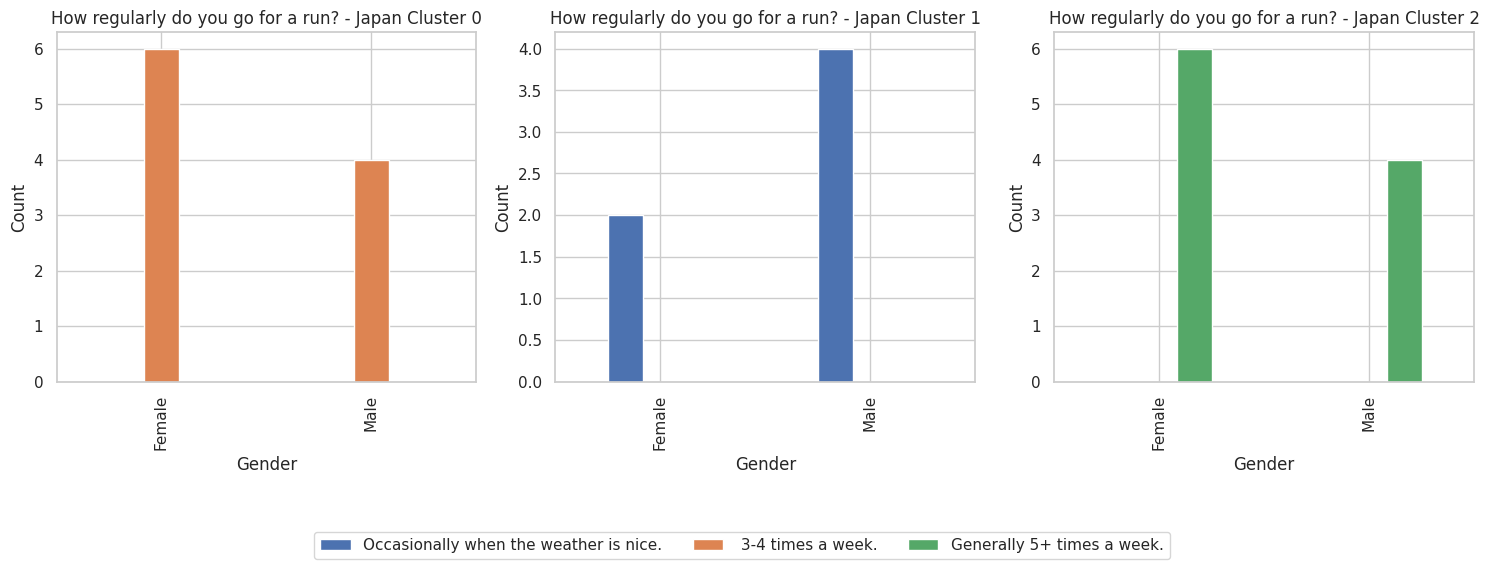

In [ ]:
# create a list of the data frames
df_run = [j_df_0, j_df_1, j_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_run):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q1r1'] == 1) | (df['Q1r2'] == 1) | (df['Q1r3'] == 1) ]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q1r1',	'Q1r2',	'Q1r3'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q1r1': 'Occasionally when the weather is nice.', 'Q1r2': ' 3-4 times a week.', 'Q1r3': 'Generally 5+ times a week.'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('How regularly do you go for a run? - Japan Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
 Similar observations are derived from Japan.
- Looking at the participants from Japan, cluster 0 is solely dedicated to females and males that go on runs 3-4 times a week. 
- Cluster 1 only has participants female and male that go occasionally when the weather is nice.
- Cluster 2 has participants female and male where they generally gor for a run 5+ times a week. 
- As mentioned, cluster two would be the most targetable group followed by cluster 0 and then 1.

### How many pairs of running shoes do you own at a time when you train?



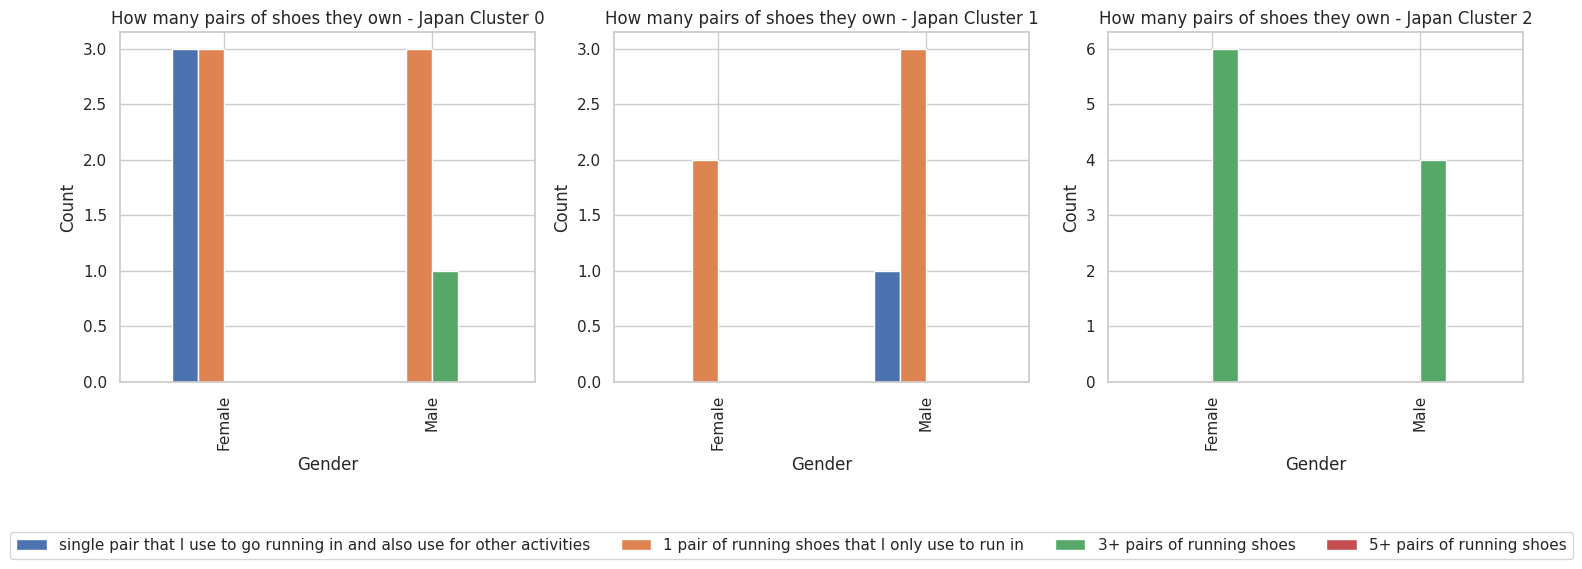

In [ ]:
# create a list of the data frames
df_pairs = [j_df_0, j_df_1, j_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_pairs):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q2r1'] == 1) | (df['Q2r2'] == 1) | (df['Q2r3'] == 1)  | (df['Q2r4'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q2r1',	'Q2r2',	'Q2r3', 'Q2r4'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q2r1': 'single pair that I use to go running in and also use for other activities', 'Q2r2': '1 pair of running shoes that I only use to run in', 'Q2r3': '3+ pairs of running shoes', 'Q2r4': '5+ pairs of running shoes'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('How many pairs of shoes they own - Japan Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()



 **Observations:** 
- Similar conclusions for each cluster are observed for participants from Japan. 
- Cluster 2 contains only participants that own more than 3 pairs of running shoes (but less than 5)
- This is followed by cluster 0 which mostly has participants that own 1 pair of running shoes used to run and one participant that owns 3+ (but less than 5) running shoes.
- Cluster 1 is mostly participants that own a single pair that are used for running across females and males.
- This conclusions suggest that males run more often as there are more males in all clusters combined owning more than 3 pairs of running shoes than there are women.

### What type of cushioning do the shoes that you train in most regularly use?

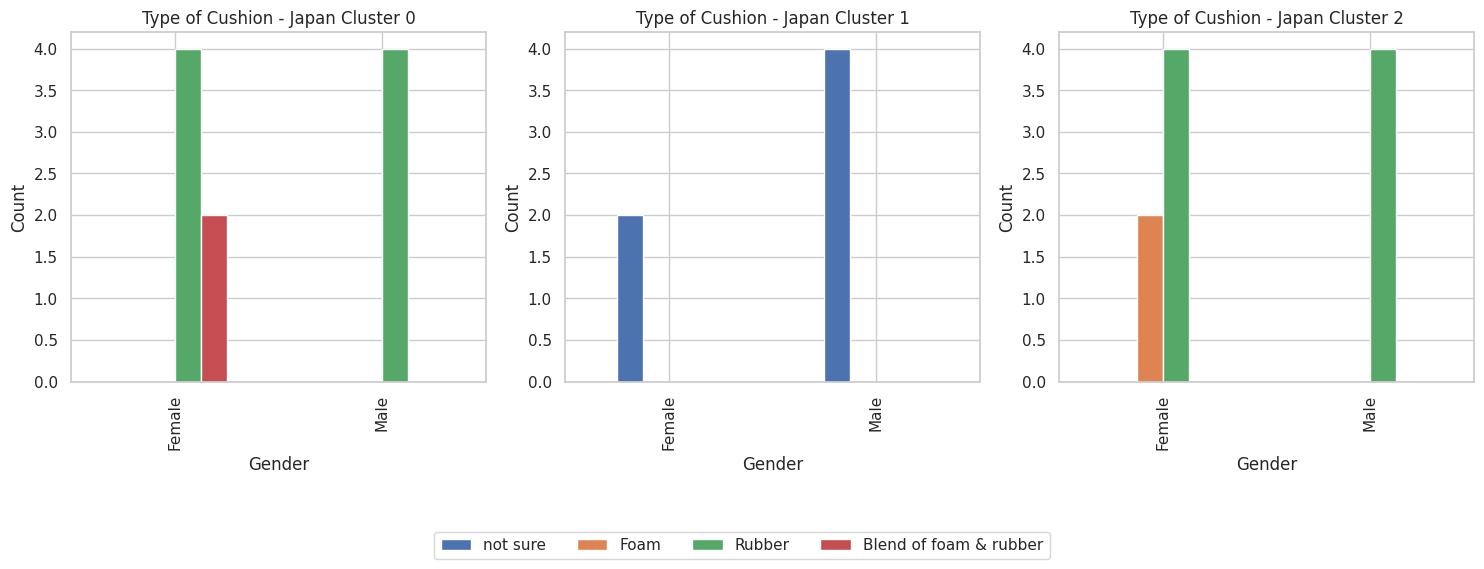

In [ ]:
# create a list of the data frames
df_cushion = [j_df_0, j_df_1, j_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_cushion):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q3r1'] == 1) | (df['Q3r2'] == 1) | (df['Q3r3'] == 1)  | (df['Q3r4'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q3r1',	'Q3r2',	'Q3r3', 'Q3r4'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q3r1': 'not sure', 'Q3r2': 'Foam', 'Q3r3': 'Rubber', 'Q3r4': 'Blend of foam & rubber'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Type of Cushion - Japan Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()




 **Observations:** 
- Based on these observations, males and females on cluster 2 participants (and the group that runs and owns more running shoes) use rubber cushioning.
- Most of cluster 0 has a combination between foam or rubber.
- On the other hand, all participants from cluster 1 don't know their cushion material. This makes sense as this cluster group only owns a single pair that they use for running and other activities.

### What type of plating do the shoes that you race in use?

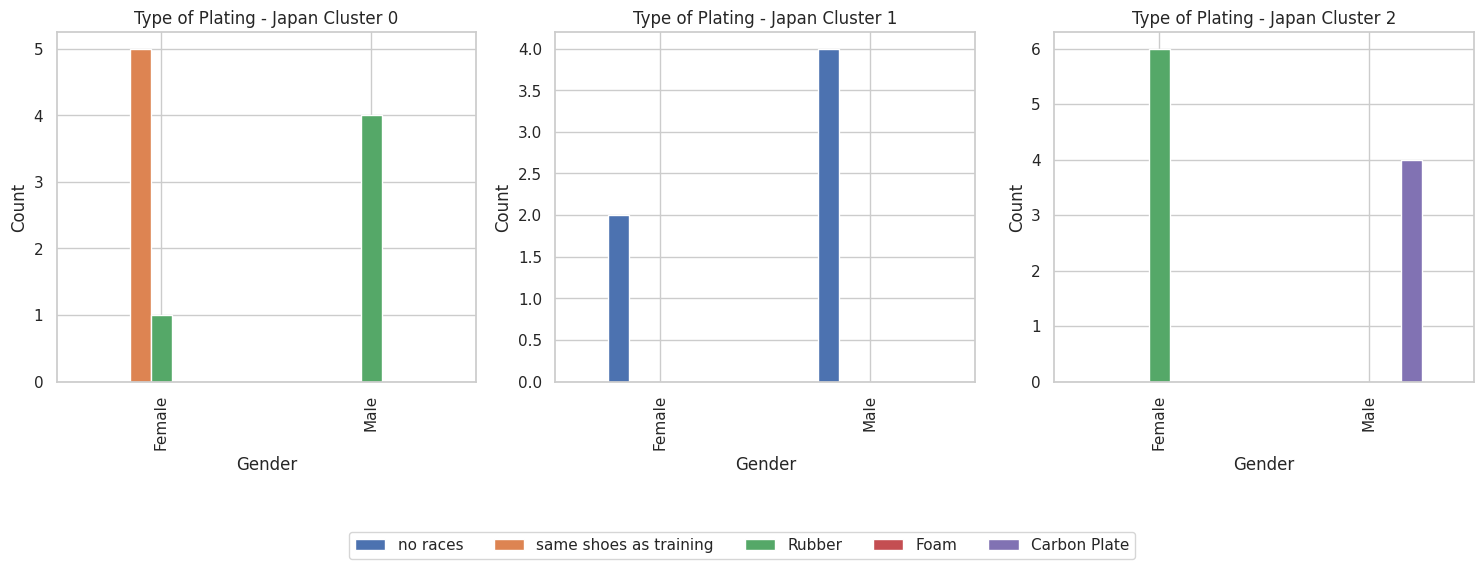

In [26]:
# create a list of the data frames
df_plat = [j_df_0, j_df_1, j_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_plat):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q4r1'] == 1) | (df['Q4r2'] == 1) | (df['Q4r3'] == 1)  | (df['Q4r4'] == 1) | (df['Q4r5'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q4r1',	'Q4r2',	'Q4r3', 'Q4r4', 'Q4r5'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q4r1': 'no races', 'Q4r2': 'same shoes as training', 'Q4r3': 'Rubber', 'Q4r4': 'Foam', 'Q4r5': 'Carbon Plate'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Type of Plating - Japan Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Similar observations to cushion type are observed for plating. Cluster 2 participants (and the group that runs and owns more running shoes) use rubber plating, follow by carbon plate. Cluster 2 also has more females than males.
- Most of cluster 0 mostly has participants where they use the same shoes as with the ones that they train with for their races. A majority of those participants are female (similar to the USA).
- On the other hand, all participants from cluster 1 say they don't race and therefore don't have racing shoes.

### What physical activities do you do outside of running?

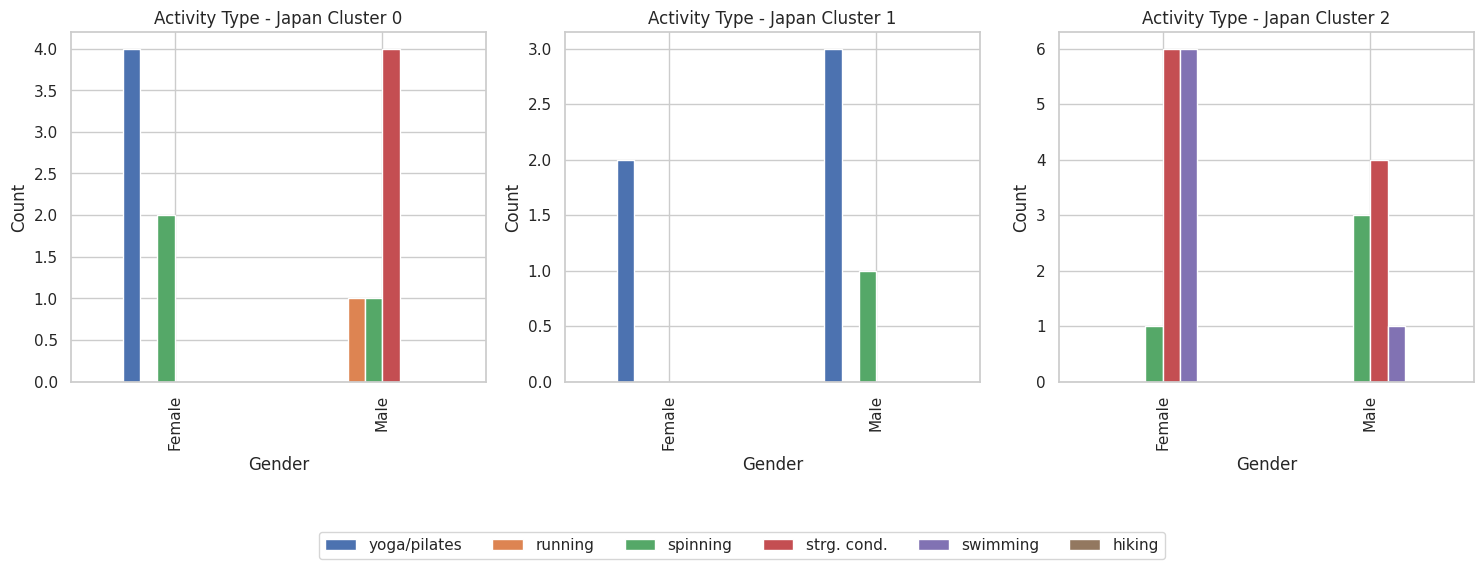

In [28]:
# create a list of the data frames
df_act = [j_df_0, j_df_1, j_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_act):
    # create a new data frame that filters only the rows where selected columns are 1s
    df_filtered = df[(df['Q5r1'] == 1) | (df['Q5r2'] == 1) | (df['Q5r3'] == 1)  | (df['Q5r4'] == 1) | (df['Q5r5'] == 1)| (df['Q5r6'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q5r1',	'Q5r2',	'Q5r3', 'Q5r4', 'Q5r5', 'Q5r6'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q5r1': 'yoga/pilates', 'Q5r2': 'running', 'Q5r3': 'spinning', 'Q5r4': 'strg. cond.', 'Q5r5': 'swimming','Q5r6': 'hiking'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Activity Type - Japan Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()

 **Observations:** 
- Similar to the USA and UK, cluster 0 females enjoy yoga/pilates and spinning. Males have some diversity between running, spinning and strenght conditioning.
- Cluster 1 has around the same number of females and males that do yoga/pilates.
- Females and males on cluster 2 enjoy strenght conditioning and swimming more than any other activity.

### What is your top complaint about the shoe you use to run in most regularly?

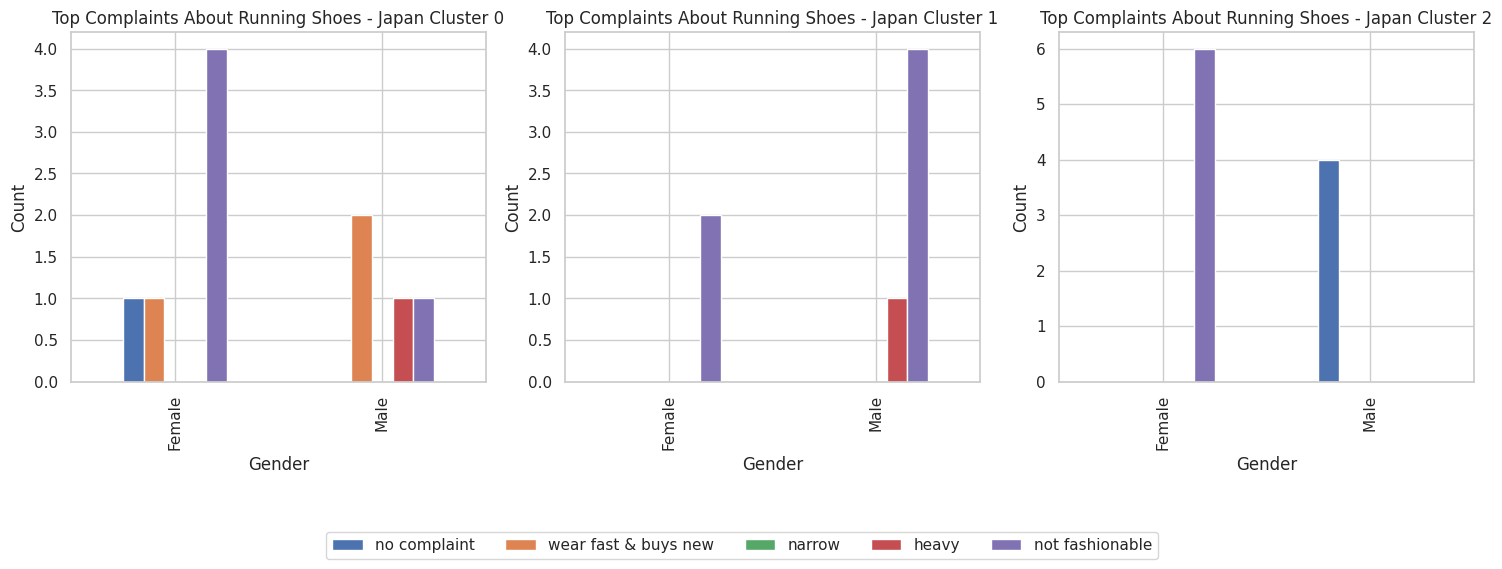

In [ ]:
# create a list of the data frames
df_list = [j_df_0, j_df_1, j_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_list):
    # create a new data frame that filters only the rows where Q6r1, Q6r2, Q6r3, Q6r4, or Q6r5 are 1s
    df_filtered = df[(df['Q6r1'] == 1) | (df['Q6r2'] == 1) | (df['Q6r3'] == 1) | (df['Q6r4'] == 1) | (df['Q6r5'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q6r1', 'Q6r2', 'Q6r3', 'Q6r4', 'Q6r5'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q6r1': 'no complaint', 'Q6r2': 'wear fast & buys new', 'Q6r3': 'narrow', 'Q6r4': 'heavy', 'Q6r5': 'not fashionable'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Top Complaints About Running Shoes - Japan Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()


 **Observations:** 
- Looking at the participants from Japan, cluster 0 seems to have more females that complaint about running shows not being fashionable. 
- Cluster 1 only has participants female and male agreeing on shoes not being fashionable enough.
- Cluster 2 has females complaining about shoes not being fashionable and males that have no complaints.

### What colors do you prefer for the shoes you run in most often?

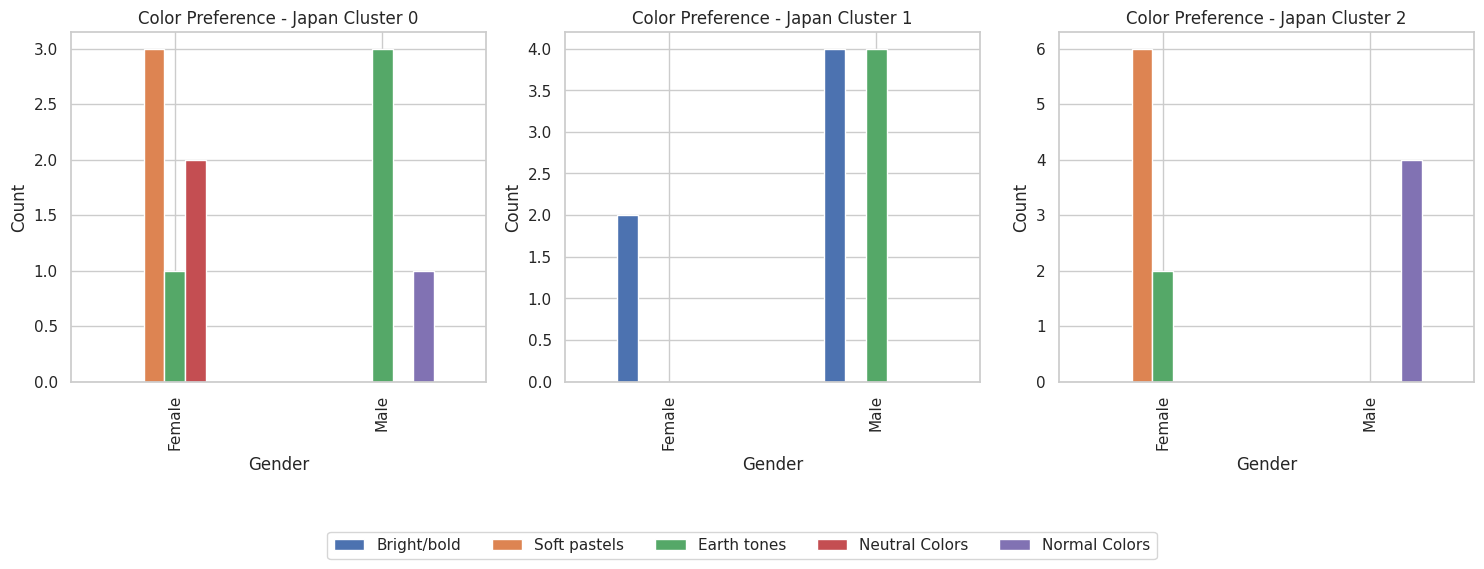

In [30]:
# create a list of the data frames
df_list = [j_df_0, j_df_1, j_df_2]

# create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))

# iterate through the data frames and plot the graphs
for i, df in enumerate(df_list):
    # create a new data frame that filters only the rows where Q6r1, Q6r2, Q6r3, Q6r4, or Q6r5 are 1s
    df_filtered = df[(df['Q7r1'] == 1) | (df['Q7r2'] == 1) | (df['Q7r3'] == 1) | (df['Q7r4'] == 1) | (df['Q7r5'] == 1)]

    # count the number of 1s in each column, grouped by S3r1
    count_df = df_filtered.groupby('S3r1')['Q7r1', 'Q7r2', 'Q7r3', 'Q7r4', 'Q7r5'].sum()

    # rename the columns to the new labels
    count_df = count_df.rename(columns={'Q7r1': 'Bright/bold', 'Q7r2': 'Soft pastels', 'Q7r3': 'Earth tones', 'Q7r4': 'Neutral Colors', 'Q7r5': 'Normal Colors'})

    # plot the data on the corresponding subplot
    count_df.plot(kind='bar', ax=axs[i])
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Female', 'Male'])
    axs[i].set_xlabel('Gender')
    axs[i].set_ylabel('Count')
    axs[i].set_title('Color Preference - Japan Cluster {}'.format(i))

    # remove the legend from each subplot
    axs[i].get_legend().remove()

# add a single legend to the bottom of the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=[0.5, -0.15])

# adjust the spacing between subplots
plt.tight_layout()

# display the plot
plt.show()

 **Observations:** 
- Looking at the participants from Japan, cluster 0 seems to have more females that want soft pastels, earth tones and neutral colors. Males prefer earth and normal colors.
- Cluster 1 is dominated by males that want earth and bright/bold colors.
- Females on cluster 2 prefer soft pastels whereas males prefer normal colors.

### Final Recommendations for participants in Japan

We would like to based off our recommendations based of the observations per each cluster group in Japan.

Starting with the group with more market opportunity: 


Cluster 0:
1. This group age distribution only includes participants age 35 through 44 years old. There are no participants that are under 18. At this age, one can assume they are more active physically but also are more finacially stable. They also go for runs 3-4 times a week which may mean they'll be purchasing running shoes more often. This is backed up by the observation that they mostly own only one pair of running shoes and three females owning only a single pair that they use for running but also for other activities. One of the complaints from this group is that their running shoes are not fashionable, specially for females.  For males, their main complaint is that they wear out too fast. Overall, this group can be targeted by making more fashonable and more resistant to wear running shoes. Females would prefer soft pastels whereas males would prefer earth tones. This can potentially incentivize them to own more than one pair of runnign shoes. 


Cluster 2:
1. This group is made by participants between age 25 to 34 years old. Similar to cluster 0,there are no participants that are under 18. At this age once can assume they are physically active and financially stable. This is backed up by the observation that they generally go for runs more than 5 times a week and owm more than 5 pair of running shoes. The top complaint from females is that their running shoes are not fashionable.  For males, there are a few that complaint about wearing out too fast and some related to not being fashionable. Overall, this group can be targeted by making more fashonable, more resistant running shoes. Females would prefer soft pastels while males prefer normal colors.We can determine that this group is an already stablished customer as they are the ones that run the most from these three cluster groups. They are perhaps the most knowlegeable in terms of running shoes in the market. However, only males said they had no complaints. 

Cluster 1:
1. This group is mostly dominated by males between 18-24 years old with 2 females belonging to this same category. At this age, one can assume, they are not necesarily in a stable financial situation.It is worth mentioning there were no participants under the age of 18 years old like in the USA and UK. One main observation from this group is that they always go for runs ocassionally when the weather is nice and usually own one single pair that is used for running. The top complaint from this group is that their running shoes are not fashionable, specially for males. Overall, this group can be targeted by making more fashonable shoes for females and males. Females from this group would prefer bright/bold colors while male would prefer earth tones but also bright/bold colors. 